In [1]:
import pandas as pd
import numpy as np

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import pickle
# Seed value
# Apparently you may use different seed values at each stage
seed_value= 1

# 1. Set `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)

# 2. Set `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)

# 3. Set `numpy` pseudo-random generator at a fixed value
import numpy as np
np.random.seed(seed_value)


# for later versions: 
# tf.compat.v1.set_random_seed(seed_value)

# 5. Configure a new global `tensorflow` session




In [8]:
file_name = 'final_resultswithclusteringfullmz.csv'
df = pd.read_csv(file_name, encoding='utf-8')

In [22]:
file_name = 'evaluation.csv'
df = pd.read_csv(file_name, encoding='utf-8')

In [15]:
file_name = 'result.csv'
df = pd.read_csv(file_name, encoding='utf-8')

In [18]:
df['residual'] = df['Predicted_CCS'] - df['CCS']

plt.figure(figsize=(6, 4))
sns.scatterplot(x='CCS', y='residual', data=df)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Experimental")
plt.ylabel("Residual (Predicted - Experimental)")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


KeyError: 'Predicted_CCS'

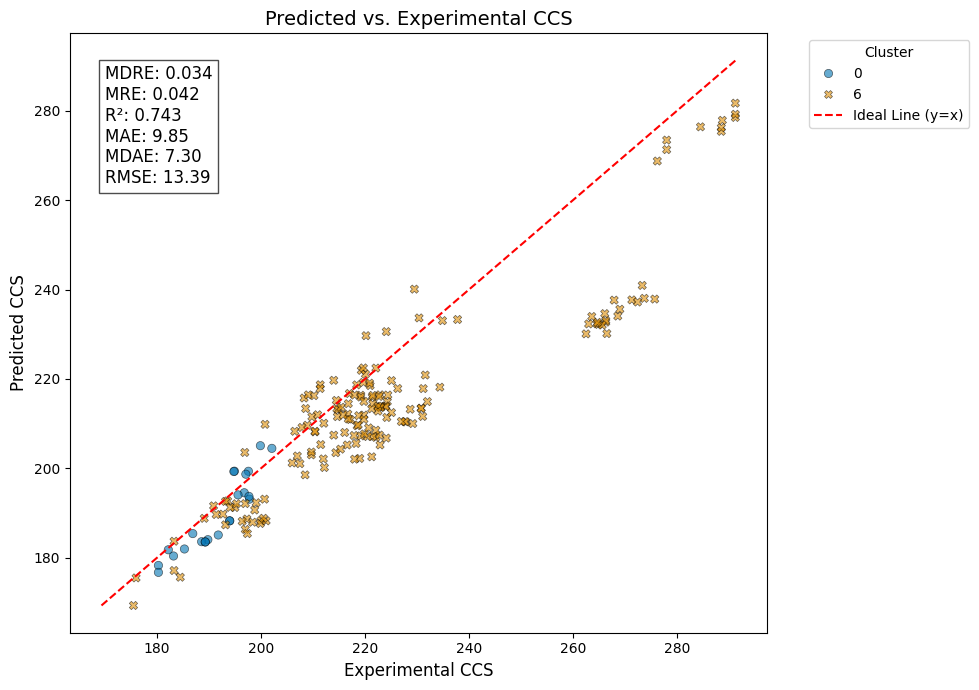

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create a 2D scatter plot showing predicted vs. experimental CCS, with clusters in different colors
plt.figure(figsize=(10, 7))

sns.scatterplot(data=df, x='CCS', y='Predicted_CCS', hue='Cluster',style='Cluster',  palette='colorblind', alpha=0.6, edgecolor='black')

# Plot y = x line (ideal prediction line)
min_val = min(df['CCS'].min(), df['Predicted_CCS'].min())
max_val = max(df['CCS'].max(), df['Predicted_CCS'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label="Ideal Line (y=x)")

# Calculate error metrics
abs_error = np.abs(df['CCS'] - df['Predicted_CCS'])
relative_error = abs_error / df['CCS']

mae = mean_absolute_error(df['CCS'], df['Predicted_CCS'])
rmse = np.sqrt(mean_squared_error(df['CCS'], df['Predicted_CCS']))
r2 = r2_score(df['CCS'], df['Predicted_CCS'])
mdae = np.median(abs_error)
mdre = np.median(relative_error)
mae = mean_absolute_error(df['CCS'], df['Predicted_CCS'])
mdae = np.median(abs_error)
mre = np.mean(relative_error)
mdre = np.median(relative_error)
rmse = np.sqrt(mean_squared_error(df['CCS'], df['Predicted_CCS']))
r2 = r2_score(df['CCS'], df['Predicted_CCS'])
stats = []
stats.append([
    round(mae, 2),
    round(mdae, 2),
    round(mre, 3),
    round(mdre, 3),
    round(rmse, 2),
    round(r2, 2)
])

# Annotate metrics on plot
metrics_text = (
    f"MDRE: {mdre:.3f}\n"
    f"MRE: {mre:.3f}\n"
    f"R²: {r2:.3f}\n"
    f"MAE: {mae:.2f}\n"
    f"MDAE: {mdae:.2f}\n"
    f"RMSE: {rmse:.2f}"
)


plt.annotate(metrics_text, xy=(0.05, 0.75), xycoords='axes fraction', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

# Labels and title
plt.xlabel("Experimental CCS", fontsize=12)
plt.ylabel("Predicted CCS", fontsize=12)
plt.title("Predicted vs. Experimental CCS", fontsize=14)
plt.tight_layout()
plt.tight_layout()

# Show legend and plot
plt.legend(title="Cluster", loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("predicted_vs_experimental_CCS.png", dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.savefig("predicted_vs_experimental_CCS.pdf", dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.rcParams["font.family"] = "sans-serif"   # فونت پیش‌فرض
plt.rcParams["svg.fonttype"] = "none"       # متن‌ها فلت نشوند (قابل انتخاب بمانند)
plt.savefig("predicted_vs_experimental_CCS.svg", format="svg", dpi=96, bbox_inches="tight")

plt.show()


Dtypes after conversion to numeric:
Experimental    float64
Allccs          float64
Allccs2         float64
DeepCCS         float64
SigamCCS        float64
FastCCS         float64
dtype: object

NaN count after filling:
Experimental    0
Allccs          0
Allccs2         0
DeepCCS         0
SigamCCS        0
FastCCS         0
dtype: int64


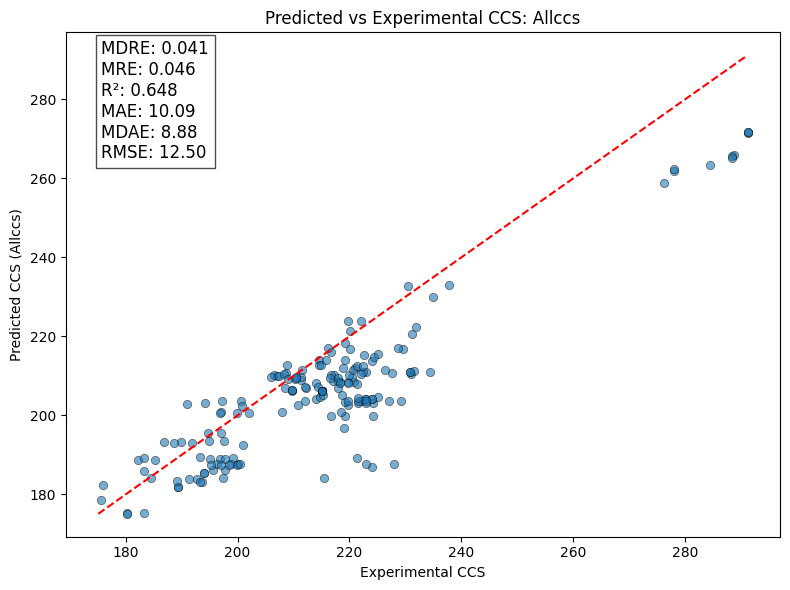

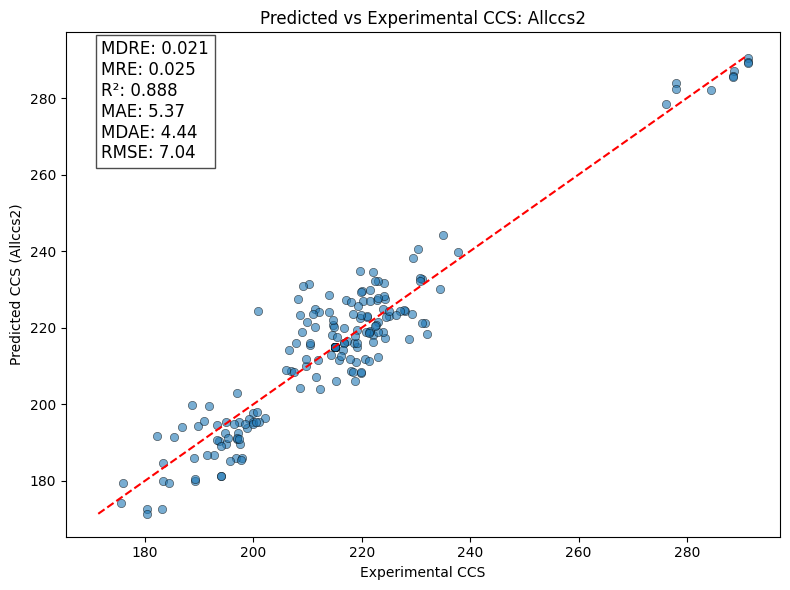

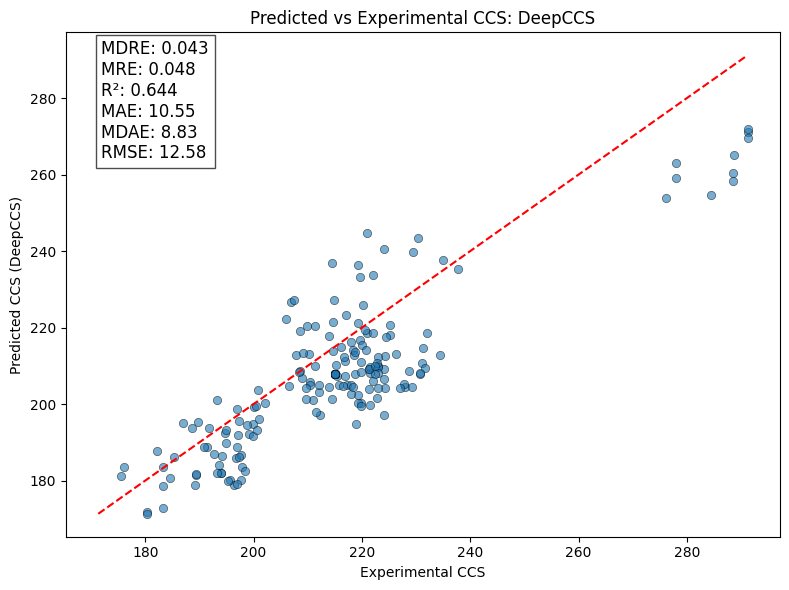

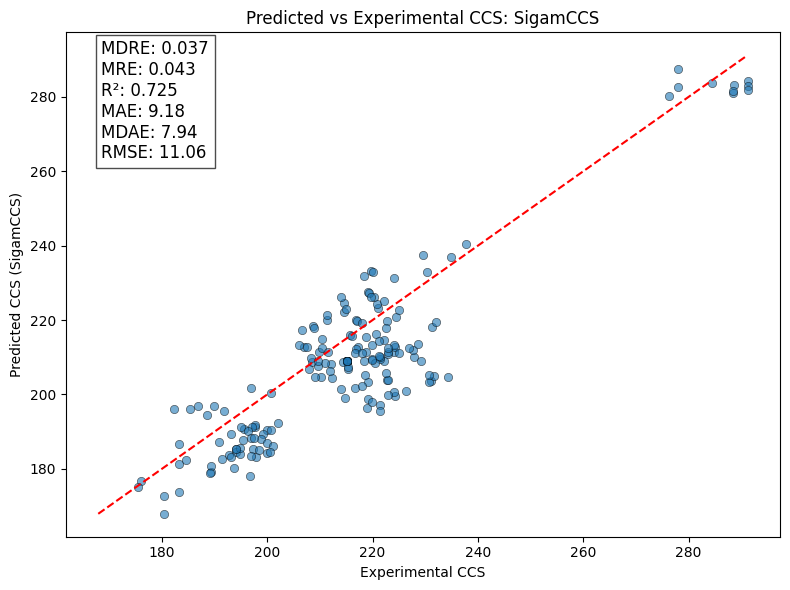

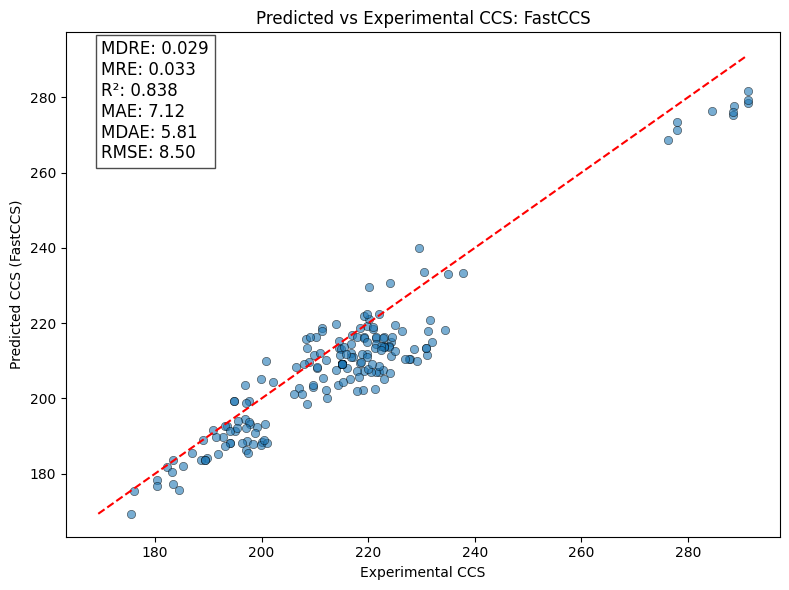

      Model    MAE  MDAE    MRE   MDRE   RMSE    R2
0    Allccs  10.09  8.88  0.046  0.041  12.50  0.65
1   Allccs2   5.37  4.44  0.025  0.021   7.04  0.89
2   DeepCCS  10.55  8.83  0.048  0.043  12.58  0.64
3  SigamCCS   9.18  7.94  0.043  0.037  11.06  0.73
4   FastCCS   7.12  5.81  0.033  0.029   8.50  0.84


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ستون‌ها
experimental_col = 'Experimental'
model_cols = [ 'Allccs', 'Allccs2', 'DeepCCS', 'SigamCCS', 'FastCCS']

# تبدیل همه به عدد (غیرقابل تبدیل -> NaN)
for col in [experimental_col] + model_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# پر کردن NaN با میانگین هر ستون
numeric_cols = [experimental_col] + model_cols
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# بررسی مجدد
print("Dtypes after conversion to numeric:")
print(df[numeric_cols].dtypes)
print("\nNaN count after filling:")
print(df[numeric_cols].isna().sum())

# دیتافریم برای ذخیره آمار خطاها
stats_list = []

for model in model_cols:
    y_true = df[experimental_col]
    y_pred = df[model]

    # محاسبه خطاها
    abs_error = np.abs(y_true - y_pred)
    relative_error = abs_error / y_true

    mae = mean_absolute_error(y_true, y_pred)
    mdae = np.median(abs_error)
    mre = np.mean(relative_error)
    mdre = np.median(relative_error)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    stats_list.append({
        'Model': model,
        'MAE': round(mae, 2),
        'MDAE': round(mdae, 2),
        'MRE': round(mre, 3),
        'MDRE': round(mdre, 3),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 2)
    })

    # رسم نمودار scatter
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, edgecolor='black')
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Ideal Line (y=x)')

    metrics_text = (
        f"MDRE: {mdre:.3f}\n"
        f"MRE: {mre:.3f}\n"
        f"R²: {r2:.3f}\n"
        f"MAE: {mae:.2f}\n"
        f"MDAE: {mdae:.2f}\n"
        f"RMSE: {rmse:.2f}"
    )

    plt.annotate(metrics_text, xy=(0.05, 0.75), xycoords='axes fraction',
                 fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
    plt.xlabel("Experimental CCS")
    plt.ylabel(f"Predicted CCS ({model})")
    plt.title(f"Predicted vs Experimental CCS: {model}")
    plt.tight_layout()
    plt.savefig(f"predicted_vs_experimental_{model.replace(' ', '_')}.png", dpi=300)
    plt.show()

# ذخیره خطاها در یک دیتافریم
stats_df = pd.DataFrame(stats_list)
print(stats_df)
stats_df.to_csv("model_error_stats.csv", index=False)


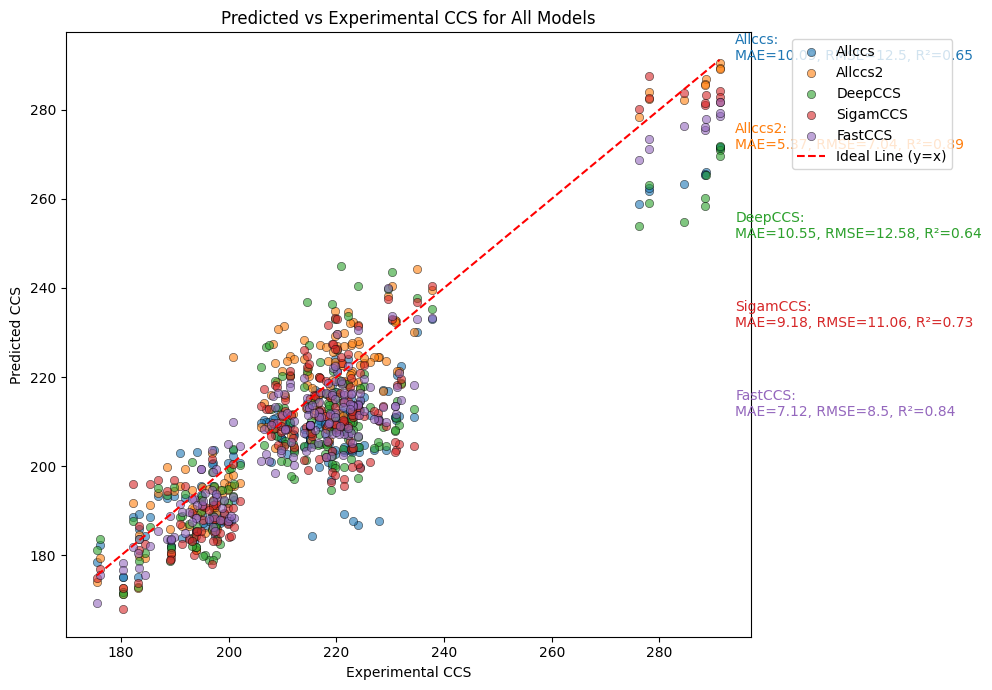

      Model    MAE  MDAE    MRE   MDRE   RMSE    R2
0    Allccs  10.09  8.88  0.046  0.041  12.50  0.65
1   Allccs2   5.37  4.44  0.025  0.021   7.04  0.89
2   DeepCCS  10.55  8.83  0.048  0.043  12.58  0.64
3  SigamCCS   9.18  7.94  0.043  0.037  11.06  0.73
4   FastCCS   7.12  5.81  0.033  0.029   8.50  0.84


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ستون‌ها
experimental_col = 'Experimental'
model_cols = [ 'Allccs', 'Allccs2', 'DeepCCS', 'SigamCCS', 'FastCCS']

# تبدیل همه به عدد (غیرقابل تبدیل -> NaN)
for col in [experimental_col] + model_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# پر کردن NaN با میانگین ستون
numeric_cols = [experimental_col] + model_cols
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# دیتافریم برای ذخیره آمار خطاها
stats_list = []

# آماده سازی نمودار
plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab10", len(model_cols))

for i, model in enumerate(model_cols):
    y_true = df[experimental_col]
    y_pred = df[model]

    # محاسبه خطاها
    abs_error = np.abs(y_true - y_pred)
    relative_error = abs_error / y_true

    mae = mean_absolute_error(y_true, y_pred)
    mdae = np.median(abs_error)
    mre = np.mean(relative_error)
    mdre = np.median(relative_error)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    stats_list.append({
        'Model': model,
        'MAE': round(mae, 2),
        'MDAE': round(mdae, 2),
        'MRE': round(mre, 3),
        'MDRE': round(mdre, 3),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 2)
    })

    # Scatter روی نمودار واحد
    sns.scatterplot(x=y_true, y=y_pred, label=model, alpha=0.6, edgecolor='black', color=palette[i])

# خط y=x
min_val = df[experimental_col].min()
max_val = df[experimental_col].max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='Ideal Line (y=x)')

# اضافه کردن متن آمار به نمودار
text_y = max_val
for i, stat in enumerate(stats_list):
    text = (f"{stat['Model']}:\n"
            f"MAE={stat['MAE']}, RMSE={stat['RMSE']}, R²={stat['R2']}")
    plt.text(max_val*1.01, text_y - i*20, text, fontsize=10, color=palette[i])

plt.xlabel("Experimental CCS")
plt.ylabel("Predicted CCS")
plt.title("Predicted vs Experimental CCS for All Models")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("predicted_vs_experimental_all_models.png", dpi=300, bbox_inches='tight')
plt.show()

# ذخیره متریک‌ها
stats_df = pd.DataFrame(stats_list)
stats_df.to_csv("all_model_error_stats.csv", index=False)
print(stats_df)


/tmp/ipykernel_106060/4030664982.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(stats_df.index, rotation=30, ha="right")
/tmp/ipykernel_106060/4030664982.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(stats_df.index, rotation=30, ha="right")
/tmp/ipykernel_106060/4030664982.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(stats_df.index, rotation=30, ha="right")
/tmp/ipykernel_106060/4030664982.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(stats_df.index, rotation=30, ha="right")
/tmp/ipykernel_106060/4030664982.py:87: UserWarning: set_tic

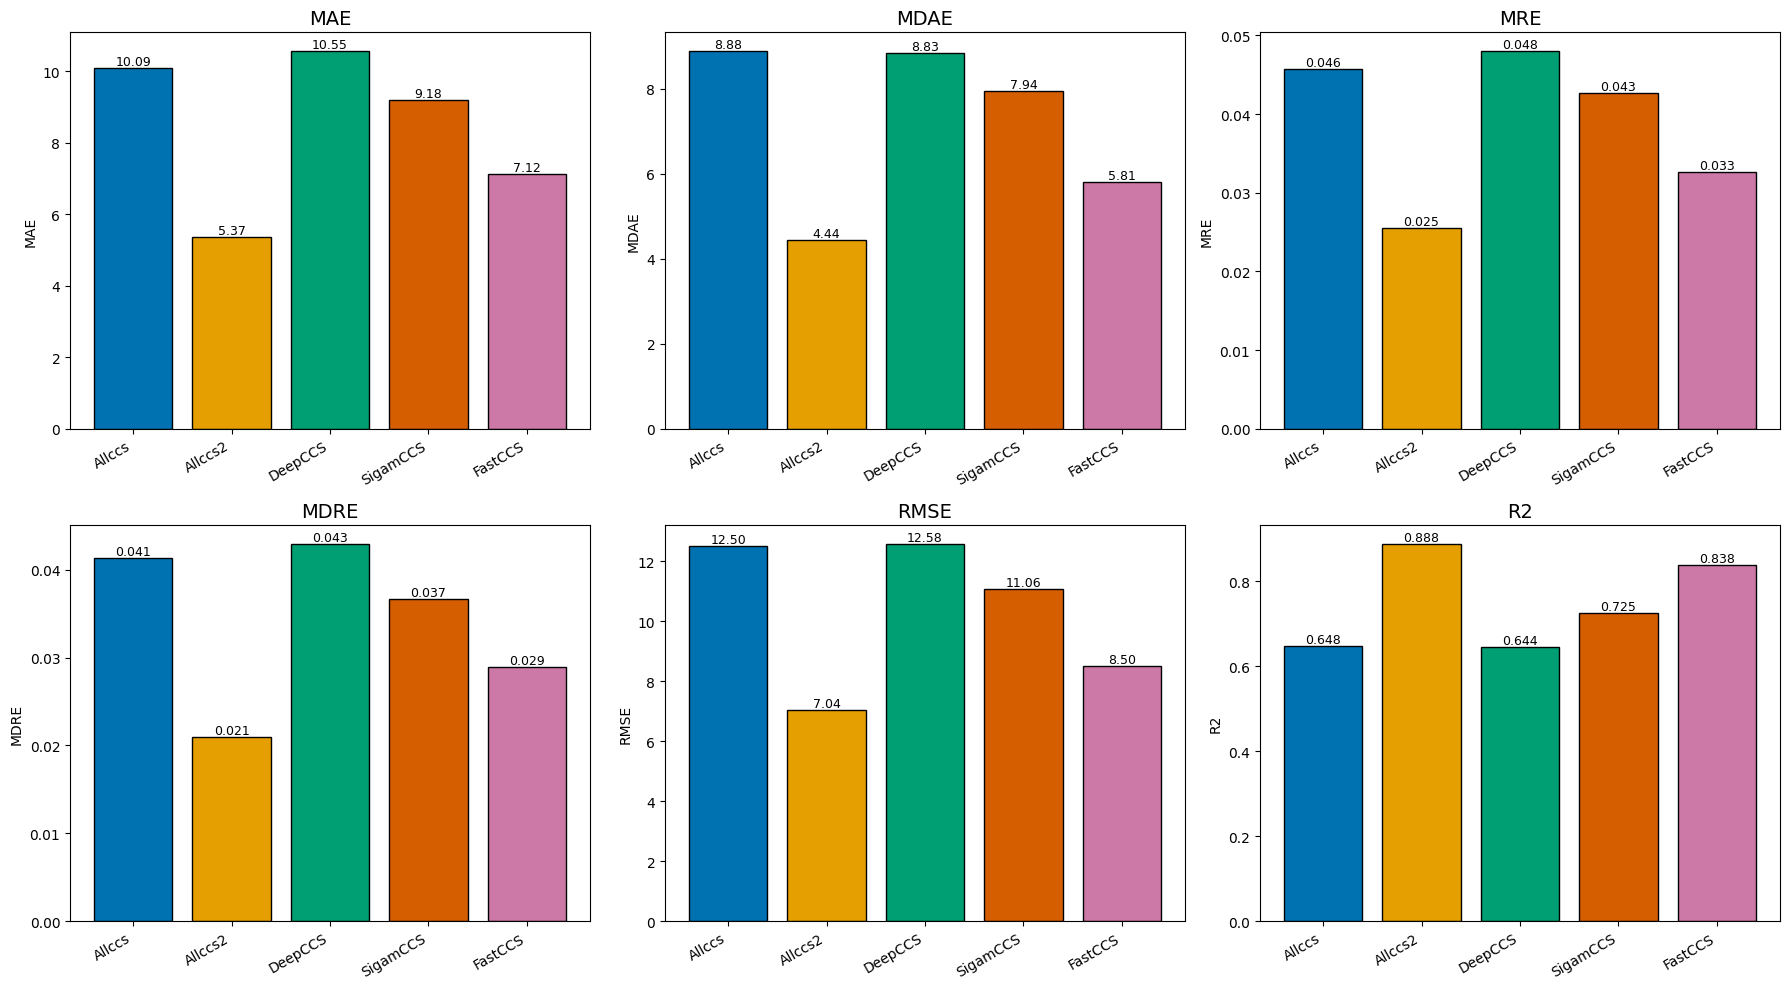

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------
# تنظیمات فونت و SVG
# -------------------------------
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["svg.fonttype"] = "none"   # متن‌ها قابل انتخاب بمانند

# پالت colorblind-safe (Okabe–Ito)
colorblind_palette = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # purple
    "#56B4E9",  # sky blue
]

# -------------------------------
# ستون‌ها
# -------------------------------
experimental_col = 'Experimental'
model_cols = [

    'Allccs',
    'Allccs2',
    'DeepCCS',
    'SigamCCS',
    'FastCCS',
]

# -------------------------------
# پاکسازی داده‌ها
# -------------------------------
for col in [experimental_col] + model_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[[experimental_col] + model_cols] = df[[experimental_col] + model_cols].fillna(
    df[[experimental_col] + model_cols].mean()
)

# -------------------------------
# محاسبه متریک‌ها
# -------------------------------
stats = []

for model in model_cols:
    y_true = df[experimental_col]
    y_pred = df[model]

    abs_error = np.abs(y_true - y_pred)
    rel_error = abs_error / y_true

    stats.append({
        "Model": model,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MDAE": np.median(abs_error),
        "MRE": np.mean(rel_error),
        "MDRE": np.median(rel_error),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    })

stats_df = pd.DataFrame(stats).set_index("Model")

# -------------------------------
# رسم نمودارهای میله‌ای
# -------------------------------
metrics = ["MAE", "MDAE", "MRE", "MDRE", "RMSE", "R2"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    bars = axes[i].bar(
        stats_df.index,
        stats_df[metric],
        color=colorblind_palette,
        edgecolor="black"
    )

    axes[i].set_title(metric, fontsize=14)
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(stats_df.index, rotation=30, ha="right")

    # نمایش مقدار روی هر میله
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}" if metric in ["MRE", "MDRE", "R2"] else f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.savefig("all_models_error_barplots.svg", format="svg", bbox_inches="tight")
plt.show()


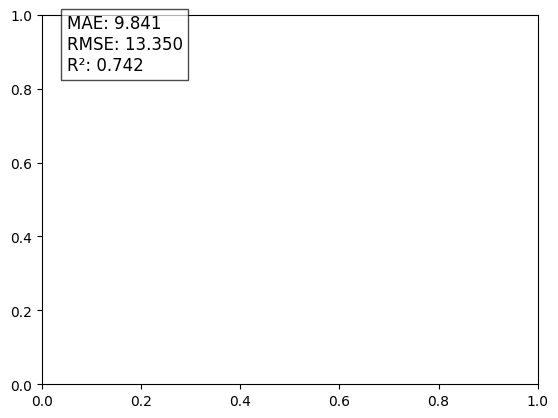

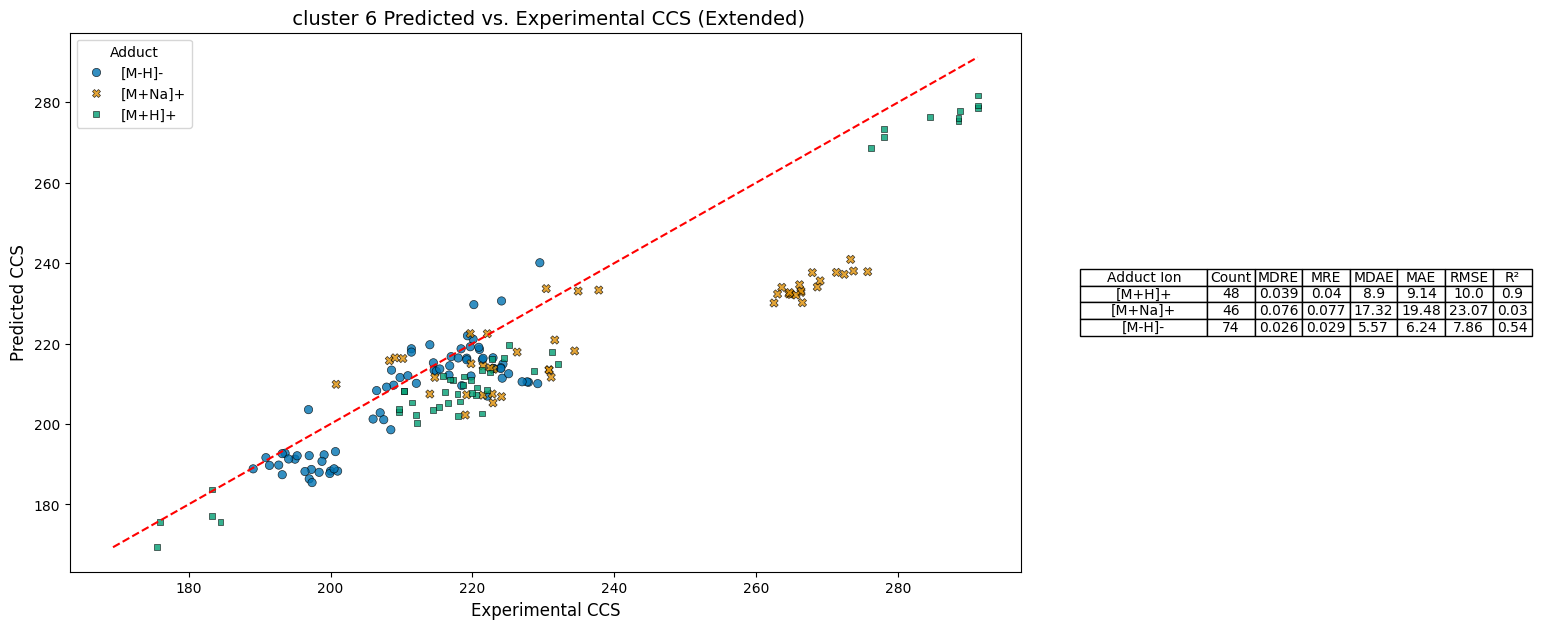

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter the dataset for Cluster 6
df_cluster = df[df['Cluster'] == 6]
# Annotate error metrics
metrics_text = f"MAE: {mae:.3f}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}"
plt.annotate(metrics_text, xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

# Compute statistics for each Adduct Ion and count of each Adduct
# Compute statistics for each Adduct Ion and count of each Adduct
stats = []
adduct_counts = df_cluster['Adduct'].value_counts()

for adduct, sub_df in df_cluster.groupby('Adduct'):
    adduct_count = adduct_counts[adduct]

    y_true = sub_df['CCS'].values
    y_pred = sub_df['Predicted_CCS'].values

    abs_error = np.abs(y_true - y_pred)
    rel_error = abs_error / y_true

    mae = mean_absolute_error(y_true, y_pred)
    mdae = np.median(abs_error)
    mre = np.mean(rel_error)
    mdre = np.median(rel_error)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    stats.append([
        adduct,
        adduct_count,
        round(mae, 2),
        round(mdae, 2),
        round(mre, 3),
        round(mdre, 3),
        round(rmse, 2),
        round(r2, 2)
    ])

# Convert to DataFrame
merged_df = pd.DataFrame(stats, columns=[
    'Adduct Ion', 'Count', 'MAE', 'MDAE', 'MRE', 'MDRE', 'RMSE', 'R²'
])
# Create figure with 2 subplots (scatter plot + merged table)
fig, ax = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [3, 1]})  # Adjust layout

# Scatter plot with Adduct as hue
sns.scatterplot(
    data=df_cluster, x='CCS', y='Predicted_CCS', hue='Adduct', style='Adduct', palette='colorblind',
     alpha=0.8, edgecolor='black', ax=ax[0]
)

# Plot y = x line
min_val = min(df_cluster['CCS'].min(), df_cluster['Predicted_CCS'].min())
max_val = max(df_cluster['CCS'].max(), df_cluster['Predicted_CCS'].max())
ax[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label="Ideal Line (y=x)")

# Labels and title
ax[0].set_xlabel("Experimental CCS", fontsize=12)
ax[0].set_ylabel("Predicted CCS", fontsize=12)
ax[0].set_title(" cluster 6 Predicted vs. Experimental CCS (Extended)", fontsize=14)

# Extract Adduct Ion symbols from the legend
handles, labels = ax[0].get_legend_handles_labels()

# Ensure the Adduct Ion symbols are ordered correctly (same order as the statistics table)
legend_labels = sorted(labels)  # Sort legend labels if necessary

# Merge the statistics into a single table
# Now, add the Adduct Ion symbols to the statistics
table_data = merged_df.values.tolist()

# Convert updated table data back to DataFrame
columns = ['Adduct Ion', 'Count', 'MAE', 'MDAE', 'MRE', 'MDRE', 'RMSE', 'R²']
final_table = pd.DataFrame(table_data, columns=columns)

# Reorder columns as requested
final_table = final_table[['Adduct Ion', 'Count', 'MDRE', 'MRE', 'MDAE', 'MAE', 'RMSE', 'R²']]

# Create the table on the second axis
ax[1].axis("tight")
ax[1].axis("off")

# Create the table with better spacing
table = ax[1].table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    cellLoc='center',
    loc='center'
)
# Font settings
table.auto_set_font_size(False)
table.set_fontsize(10)

# Manually adjust column widths (use this instead of auto_set_column_width)
col_widths = [0.4, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15]  # Adjust as needed based on number of columns

# Apply widths to all cells
for i, width in enumerate(col_widths):
    for (row, col), cell in table.get_celld().items():
        if col == i:
            cell.set_width(width)

# Optionally increase figure width if still tight
fig.set_size_inches(18, 7)  # Wider canvas

# Save the figure
plt.savefig("Predicted vs. Experimental CCS small molecules.png", dpi=300, bbox_inches="tight")
plt.savefig("Predicted vs. Experimental CCS small molecules.pdf", dpi=300, bbox_inches="tight")
plt.rcParams["font.family"] = "sans-serif"   # فونت پیش‌فرض
plt.rcParams["svg.fonttype"] = "none"       # متن‌ها فلت نشوند (قابل انتخاب بمانند)
plt.savefig("cluster_6_Predicted_vs._Experimental_CCS.svg", format="svg", dpi=96, bbox_inches="tight")

# Show the combined plot
plt.show()


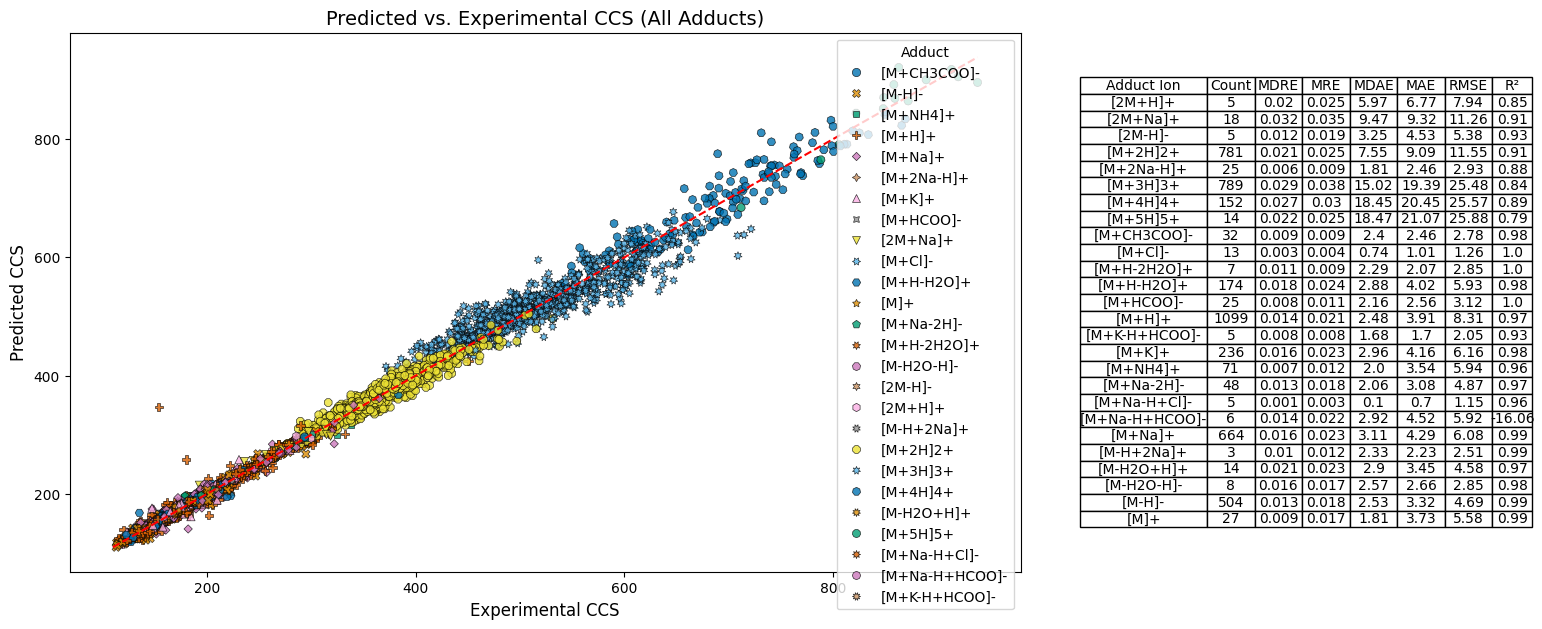

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute statistics for each Adduct Ion and count of each Adduct
stats = []
adduct_counts = df['Adduct'].value_counts()

for adduct, sub_df in df.groupby('Adduct'):
    adduct_count = adduct_counts[adduct]

    y_true = sub_df['CCS'].values
    y_pred = sub_df['Predicted_CCS'].values

    abs_error = np.abs(y_true - y_pred)
    rel_error = abs_error / y_true

    mae = mean_absolute_error(y_true, y_pred)
    mdae = np.median(abs_error)
    mre = np.mean(rel_error)
    mdre = np.median(rel_error)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    stats.append([
        adduct,
        adduct_count,
        round(mae, 2),
        round(mdae, 2),
        round(mre, 3),
        round(mdre, 3),
        round(rmse, 2),
        round(r2, 2)
    ])

# Convert to DataFrame
merged_df = pd.DataFrame(stats, columns=[
    'Adduct Ion', 'Count', 'MAE', 'MDAE', 'MRE', 'MDRE', 'RMSE', 'R²'
])

# Create figure with 2 subplots (scatter plot + merged table)
fig, ax = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [3, 1]})  # Adjust layout

# Scatter plot with Adduct as hue
sns.scatterplot(
    data=df, x='CCS', y='Predicted_CCS', hue='Adduct', style='Adduct', palette='colorblind',
    alpha=0.8, edgecolor='black', ax=ax[0]
)

# Plot y = x line
min_val = min(df['CCS'].min(), df['Predicted_CCS'].min())
max_val = max(df['CCS'].max(), df['Predicted_CCS'].max())
ax[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label="Ideal Line (y=x)")

# Labels and title
ax[0].set_xlabel("Experimental CCS", fontsize=12)
ax[0].set_ylabel("Predicted CCS", fontsize=12)
ax[0].set_title("Predicted vs. Experimental CCS (All Adducts)", fontsize=14)

# Extract Adduct Ion symbols from the legend
handles, labels = ax[0].get_legend_handles_labels()

# Ensure the Adduct Ion symbols are ordered correctly (same order as the statistics table)
legend_labels = sorted(labels)  # Sort legend labels if necessary

# Merge the statistics into a single table
# Now, add the Adduct Ion symbols to the statistics
table_data = merged_df.values.tolist()

# Convert updated table data back to DataFrame
columns = ['Adduct Ion', 'Count', 'MAE', 'MDAE', 'MRE', 'MDRE', 'RMSE', 'R²']
final_table = pd.DataFrame(table_data, columns=columns)

# Reorder columns as requested
final_table = final_table[['Adduct Ion', 'Count', 'MDRE', 'MRE', 'MDAE', 'MAE', 'RMSE', 'R²']]

# Create the table on the second axis
ax[1].axis("tight")
ax[1].axis("off")

# Create the table with better spacing
table = ax[1].table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    cellLoc='center',
    loc='center'
)
# Font settings
table.auto_set_font_size(False)
table.set_fontsize(10)

# Manually adjust column widths (use this instead of auto_set_column_width)
col_widths = [0.4, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15]  # Adjust as needed based on number of columns

# Apply widths to all cells
for i, width in enumerate(col_widths):
    for (row, col), cell in table.get_celld().items():
        if col == i:
            cell.set_width(width)

# Optionally increase figure width if still tight
fig.set_size_inches(18, 7)  # Wider canvas

# Save the figure
plt.savefig("Predicted_vs_Experimental_CCS_all_adducts.png", dpi=300, bbox_inches="tight")
plt.savefig("Predicted_vs_Experimental_CCS_all_adducts.pdf", dpi=300, bbox_inches="tight")
plt.rcParams["font.family"] = "sans-serif"   # Default font
plt.rcParams["svg.fonttype"] = "none"       # Text stays selectable in SVG
plt.savefig("Predicted_vs_Experimental_CCS_all_adducts.svg", format="svg", dpi=96, bbox_inches="tight")

# Show the combined plot
plt.show()


In [10]:
import pandas as pd

# داده‌های شما به شکل یک دیکشنری فرضی
data = {
    'Adduct Ion': ['[M+H]', '[M+Na]+', '[M+3H]³+', '[M+2H]²+', '[M+K]+', '[M-H]-', '[M+H-H2O]+', '[M+Na]+', '[M+HCOO]-', '[M+Na-2H]-', '[M+CH3COO]-', '[M+Na-H+Cl]-', '[M+K-H+HCOO]-', '[2M+H]+', '[2M+Na]+', '[M-H+2Na]+', '[M-H2O+H]+', '[M-H2O-H]-', '[M+5H]5+', '[M+4H]4+', '[M+Na-H+Cl]-', '[M+H]+'],
    'Count': [1099, 664, 789, 781, 236, 504, 174, 664, 25, 48, 32, 5, 5, 5, 3, 14, 8, 14, 152, 14, 5, 1099],
    'MDRE': [0.014, 0.016, 0.029, 0.021, 0.016, 0.013, 0.018, 0.016, 0.008, 0.013, 0.009, 0.001, 0.008, 0.02, 0.032, 0.01, 0.021, 0.016, 0.022, 0.027, 0.022, 0.014],
    'MRE': [0.021, 0.023, 0.038, 0.025, 0.023, 0.018, 0.024, 0.023, 0.011, 0.018, 0.009, 0.003, 0.008, 0.025, 0.035, 0.012, 0.023, 0.017, 0.025, 0.030, 0.025, 0.021],
    'MDAE': [2.48, 3.11, 15.02, 7.55, 2.96, 2.53, 2.88, 3.11, 2.16, 2.06, 2.4, 0.1, 1.68, 5.97, 9.47, 2.33, 2.9, 2.57, 18.47, 18.45, 18.47, 2.48],
    'MAE': [3.91, 4.29, 19.39, 9.09, 4.16, 3.32, 4.02, 4.29, 2.56, 3.08, 2.46, 0.7, 1.7, 6.77, 9.32, 2.23, 3.45, 2.66, 21.07, 20.45, 21.07, 3.91],
    'RMSE': [8.31, 6.08, 25.48, 11.55, 6.16, 4.69, 5.93, 6.08, 3.12, 4.87, 2.78, 1.15, 2.05, 7.94, 11.26, 2.51, 4.58, 2.85, 25.88, 25.57, 25.88, 8.31],
    'R²': [0.97, 0.99, 0.84, 0.91, 0.98, 0.99, 0.98, 0.99, 1.0, 0.97, 0.98, 0.96, 0.93, 0.85, 0.91, 0.99, 0.97, 0.98, 0.79, 0.89, 0.79, 0.97]
}

# ایجاد دیتافریم
df = pd.DataFrame(data)

# مرتب‌سازی بر اساس ستون 'Count' به صورت نزولی
df_sorted = df.sort_values(by='Count', ascending=False)

# نمایش جدول مرتب‌شده
print(df_sorted)


       Adduct Ion  Count   MDRE    MRE   MDAE    MAE   RMSE    R²
0           [M+H]   1099  0.014  0.021   2.48   3.91   8.31  0.97
21         [M+H]+   1099  0.014  0.021   2.48   3.91   8.31  0.97
2        [M+3H]³+    789  0.029  0.038  15.02  19.39  25.48  0.84
3        [M+2H]²+    781  0.021  0.025   7.55   9.09  11.55  0.91
7         [M+Na]+    664  0.016  0.023   3.11   4.29   6.08  0.99
1         [M+Na]+    664  0.016  0.023   3.11   4.29   6.08  0.99
5          [M-H]-    504  0.013  0.018   2.53   3.32   4.69  0.99
4          [M+K]+    236  0.016  0.023   2.96   4.16   6.16  0.98
6      [M+H-H2O]+    174  0.018  0.024   2.88   4.02   5.93  0.98
18       [M+5H]5+    152  0.022  0.025  18.47  21.07  25.88  0.79
9      [M+Na-2H]-     48  0.013  0.018   2.06   3.08   4.87  0.97
10    [M+CH3COO]-     32  0.009  0.009   2.40   2.46   2.78  0.98
8       [M+HCOO]-     25  0.008  0.011   2.16   2.56   3.12  1.00
15     [M-H+2Na]+     14  0.010  0.012   2.33   2.23   2.51  0.99
19       [

In [ ]:
## Clip residuals to focus on central distribution
df['residual_clipped'] = df['residual'].clip(lower=-50, upper=50)

plt.figure(figsize=(6, 4))
sns.histplot(df['residual_clipped'], bins=30, kde=True)
plt.xlabel("Residual (clipped to ±50)")
plt.title("Residual Histogram")
plt.grid(True)
plt.tight_layout()
plt.savefig("residualhist.png", dpi=600, bbox_inches="tight")
plt.rcParams["font.family"] = "sans-serif"   # فونت پیش‌فرض
plt.rcParams["svg.fonttype"] = "none"       # متن‌ها فلت نشوند (قابل انتخاب بمانند)
plt.savefig("Residual Histogram.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create figure
plt.figure(figsize=(10, 7))

# Scatter plot with Adduct as hue
scatter = sns.scatterplot(
    data=df, x='CCS', y='Predicted_CCS', hue='Adduct', style='Adduct',
    alpha=0.6, edgecolor='black', palette='colorblind'
)

# Plot y = x line (perfect predictions)
min_val = min(df['CCS'].min(), df['Predicted_CCS'].min())
max_val = max(df['CCS'].max(), df['Predicted_CCS'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label="Ideal Line (y=x)")

# Labels and title
plt.xlabel("Experimental CCS (Å²)", fontsize=12)
plt.ylabel("Predicted CCS (Å²)", fontsize=12)
plt.title("Cluster 3 Predicted vs. Experimental CCS", fontsize=14)

# Calculate error metrics
abs_error = np.abs(df['CCS'] - df['Predicted_CCS'])
relative_error = abs_error / df['CCS']

mae = mean_absolute_error(df['CCS'], df['Predicted_CCS'])
rmse = np.sqrt(mean_squared_error(df['CCS'], df['Predicted_CCS']))
r2 = r2_score(df['CCS'], df['Predicted_CCS'])
mdae = np.median(abs_error)
mdre = np.median(relative_error)
mre = np.mean(relative_error)



# Annotate metrics on plot
metrics_text = (
    f"MDRE: {mdre:.3f}\n"
    f"MRE: {mre:.3f}\n"
    f"R²: {r2:.3f}\n"
    f"MAE: {mae:.2f}\n"
    f"MDAE: {mdae:.2f}\n"
    f"RMSE: {rmse:.2f}\n"
    
   
)
plt.annotate(metrics_text, xy=(0.05, 0.75), xycoords='axes fraction', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

# Move legend outside for better visibility
plt.legend(title="Adduct Ion", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("small molecles_vs_experimental_CCS_adduct.png", dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.savefig("small molecles_vs_experimental_CCS_adduct.pdf", dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.rcParams["font.family"] = "sans-serif"   # فونت پیش‌فرض
plt.rcParams["svg.fonttype"] = "none"       # متن‌ها فلت نشوند (قابل انتخاب بمانند)
plt.savefig("cluster_3_predicted_vs_experimental_CCS_adduct.svg", format="svg", dpi=96, bbox_inches="tight")
# Show plot
plt.show()


ValueError: Could not interpret value `Predicted_CCS` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x700 with 0 Axes>

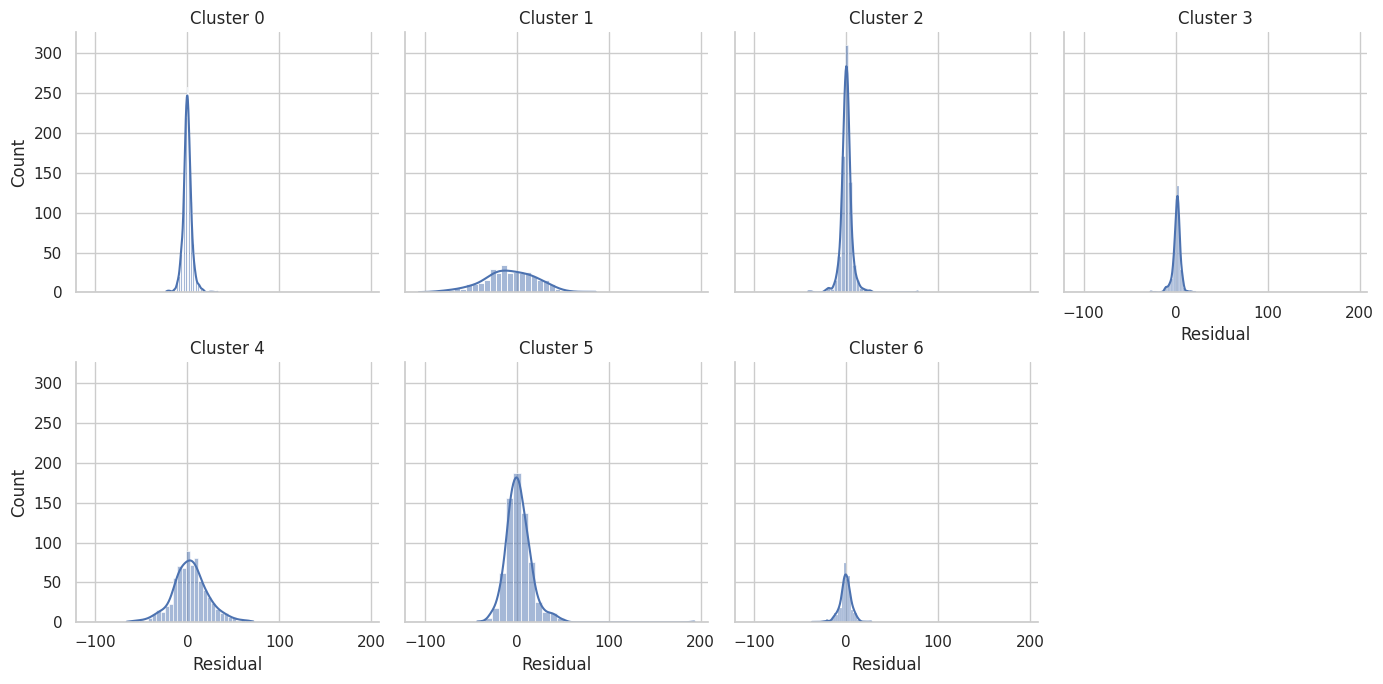

In [17]:
g = sns.FacetGrid(df, col="Cluster", col_wrap=4, height=3.5)
g.map(sns.histplot, "residual", bins=30, kde=True)
g.set_titles("Cluster {col_name}")
g.set_axis_labels("Residual", "Count")
plt.tight_layout()
plt.savefig("clusterhist.png", dpi=600, bbox_inches="tight")
plt.savefig("clusterhist.pdf", dpi=600, bbox_inches="tight")
plt.rcParams["font.family"] = "sans-serif"   # فونت پیش‌فرض
plt.rcParams["svg.fonttype"] = "none"       # متن‌ها فلت نشوند (قابل انتخاب بمانند)
plt.savefig("clusterhist.SVG", format="svg", dpi=300, bbox_inches="tight")
plt.show()


KeyError: 'm/z'

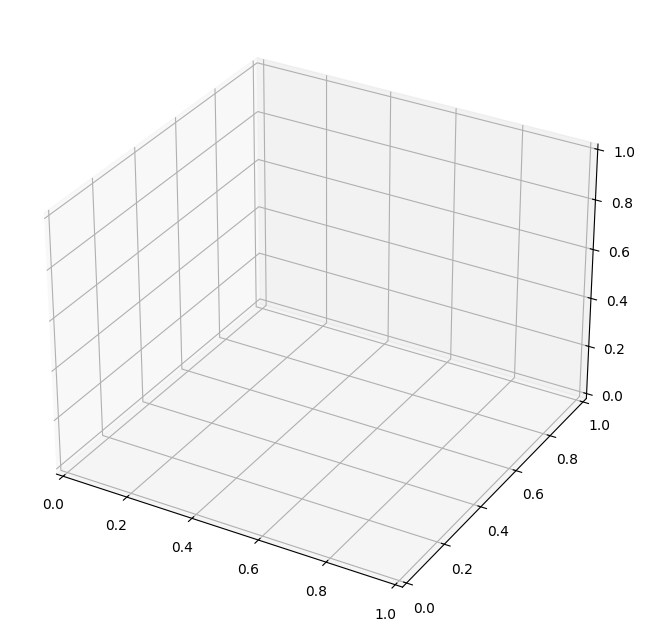

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
palette = sns.color_palette("colorblind", n_colors=df['Cluster'].nunique())

# Scatter plot
ax.scatter(df['CCS'], df['Predicted_CCS'], df['m/z'], 
           c=df['m/z'], cmap='viridis', alpha=0.7)

# Labels and title
ax.set_xlabel("Experimental CCS")
ax.set_ylabel("Predicted CCS")
ax.set_zlabel("m/z")
ax.set_title("3D Scatter: CCS vs Predicted_CCS vs m/z")
plt.rcParams["font.family"] = "sans-serif"   # فونت پیش‌فرض
plt.rcParams["svg.fonttype"] = "none"       # متن‌ها فلت نشوند (قابل انتخاب بمانند)
plt.savefig("CCS vs Predicted_CCS vs.svg", format="svg", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


In [13]:
print(type(df['Cluster']))
print(df.head())
print(df.index)


<class 'pandas.core.series.Series'>
                                              Smiles       Adduct     CCS  \
0  [C@](COP(=O)([O-])OCC[N+](C)(C)C)([H])(OC(CCCC...  [M+CH3COO]-  298.67   
1  [C@](COP(=O)(O)O)([H])(OC(CCCCCCCCC/C=C\CCCCCC...     [M+NH4]+  277.20   
2  [C@](COP(=O)([O-])OCC[N+](C)(C)C)([H])(OC(CCCC...       [M+H]+  288.47   
3    CCCCCCCC/C=C/CCCCCCCCOP(=O)([O-])OCC[N+](C)(C)C       [M+H]+  215.20   
4  C(O)(=O)[C@@]([H])(N)COP(OC[C@]([H])(O)COC(CCC...       [M+H]+  224.20   

   Predicted_CCS Cluster  residual  \
0      298.14804       6  -0.52196   
1      272.49026       6  -4.70974   
2      285.99050       6  -2.47950   
3      217.65108       6   2.45108   
4      222.48772       6  -1.71228   

                                               color       mean     diff  \
0  (0.984313725490196, 0.6862745098039216, 0.8941...  298.40902 -0.52196   
1  (0.984313725490196, 0.6862745098039216, 0.8941...  274.84513 -4.70974   
2  (0.984313725490196, 0.6862745098039216, 0

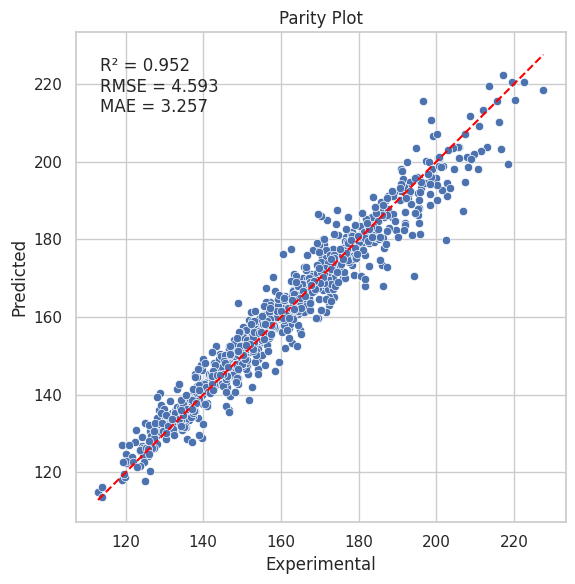

In [28]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2 = r2_score(df['CCS'], df['Predicted_CCS'])
rmse = np.sqrt(mean_squared_error(df['CCS'], df['Predicted_CCS']))
mae = mean_absolute_error(df['CCS'], df['Predicted_CCS'])

plt.figure(figsize=(6, 6))
sns.scatterplot(x='CCS', y='Predicted_CCS', data=df)
plt.plot([df['CCS'].min(), df['CCS'].max()],
         [df['CCS'].min(), df['CCS'].max()],
         color='red', linestyle='--')  # y = x line
plt.xlabel("Experimental")
plt.ylabel("Predicted")
plt.title("Parity Plot")

# Show metrics on plot
plt.text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}',
         transform=plt.gca().transAxes, verticalalignment='top')

plt.axis('square')
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_842/684549285.py:27: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='CCS', y='residual', data=df, palette='colorblind')


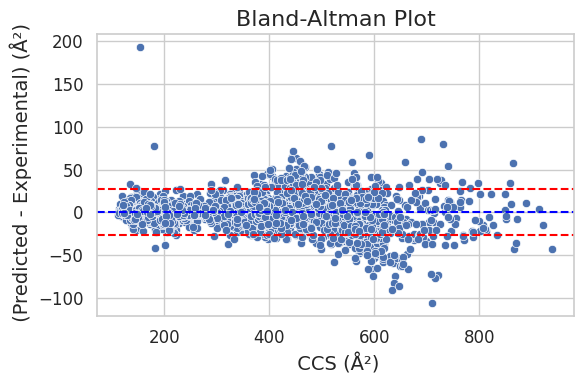

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# محاسبه مقادیر میانگین و تفاوت
df['mean'] = df[['CCS', 'Predicted_CCS']].mean(axis=1)
df['diff'] = df['Predicted_CCS'] - df['CCS']
mean_diff = df['diff'].mean()
std_diff = df['diff'].std()

# تنظیمات فونت‌ها و SVG
plt.rcParams.update({
    "font.family": "sans-serif",  # فونت مناسب مقاله
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "svg.fonttype": "none"  # فونت‌ها قابل انتخاب و ویرایش
})

# سایز شکل
plt.figure(figsize=(6, 4))

# رسم نمودار با پالت "colorblind"
sns.scatterplot(x='CCS', y='residual', data=df, palette='colorblind')

# خطوط میانه و 1.96 انحراف معیار
plt.axhline(mean_diff, color='blue', linestyle='--')
plt.axhline(mean_diff + 1.96*std_diff, color='red', linestyle='--')
plt.axhline(mean_diff - 1.96*std_diff, color='red', linestyle='--')

# برچسب‌ها و عنوان
plt.ylabel(" (Predicted - Experimental) (Å²)", fontsize=14)
plt.xlabel(" CCS (Å²)", fontsize=14)

plt.title("Bland-Altman Plot", fontsize=16)

# فعال کردن شبکه خطوط عمودی و افقی
plt.grid(True)

# تنظیم فاصله‌ها برای جلوگیری از تداخل
plt.tight_layout()

# ذخیره به فرمت SVG با وضوح بالا و قابل ویرایش
plt.savefig("bland.svg", format="svg", dpi=300, bbox_inches="tight")

# نمایش نمودار
plt.show()


In [31]:
for adduct, group in df.groupby('Cluster'):
    file_name = f"graph_{adduct}.csv"
    group.to_csv(file_name, index=False, encoding='utf-8')
    print(f"Saved: {file_name}")

/tmp/ipykernel_845/2575553651.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for adduct, group in df.groupby('Cluster'):


Saved: graph_0.csv
Saved: graph_2.csv
Saved: graph_4.csv
Saved: graph_5.csv
Saved: graph_3.csv
Saved: graph_6.csv
Saved: graph_1.csv


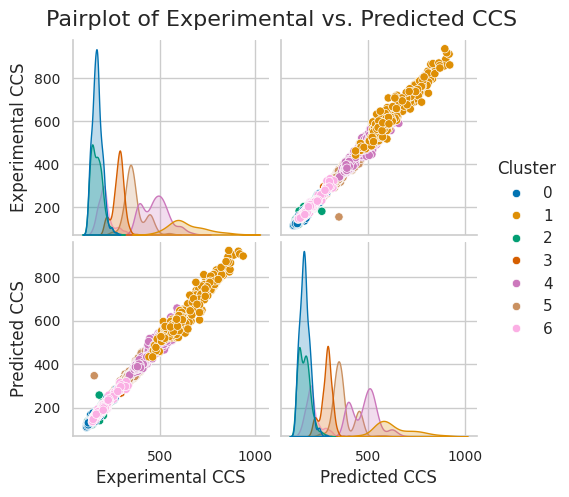

In [46]:
import matplotlib.pyplot as plt

# =========================
# رسم pairplot
# =========================
g = sns.pairplot(df, vars=['CCS', 'Predicted_CCS'], hue='Cluster', palette='colorblind')

# اضافه کردن عنوان به کل figure
g.fig.suptitle("Pairplot of Experimental vs. Predicted CCS", fontsize=16)
g.fig.subplots_adjust(top=0.92)  # تنظیم فضا برای عنوان

# تنظیم اندازه فونت برای برچسب‌های محورها
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)

# تغییر برچسب‌ها (اختیاری)
label_map = {
    'CCS': 'Experimental CCS',
    'Predicted_CCS': 'Predicted CCS'
}
for ax in g.axes.flatten():
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel in label_map:
        ax.set_xlabel(label_map[xlabel], fontsize=12)
    if ylabel in label_map:
        ax.set_ylabel(label_map[ylabel], fontsize=12)

# =========================
# تنظیمات publication-ready
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",  # فونت مناسب مقاله
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "svg.fonttype": "none"  # فونت‌ها قابل انتخاب و ویرایش
})

# ذخیره خروجی با کیفیت بالا
plt.savefig("Experimental_vs_Predicted_CCS_pairplot.png", dpi=300, bbox_inches="tight")
plt.savefig("Experimental_vs_Predicted_CCS_pairplot.pdf", dpi=300, bbox_inches="tight")
plt.savefig("Experimental_vs_Predicted_CCS_pairplot.svg", format="svg", dpi=96, bbox_inches="tight")

# نمایش نمودار
plt.show()


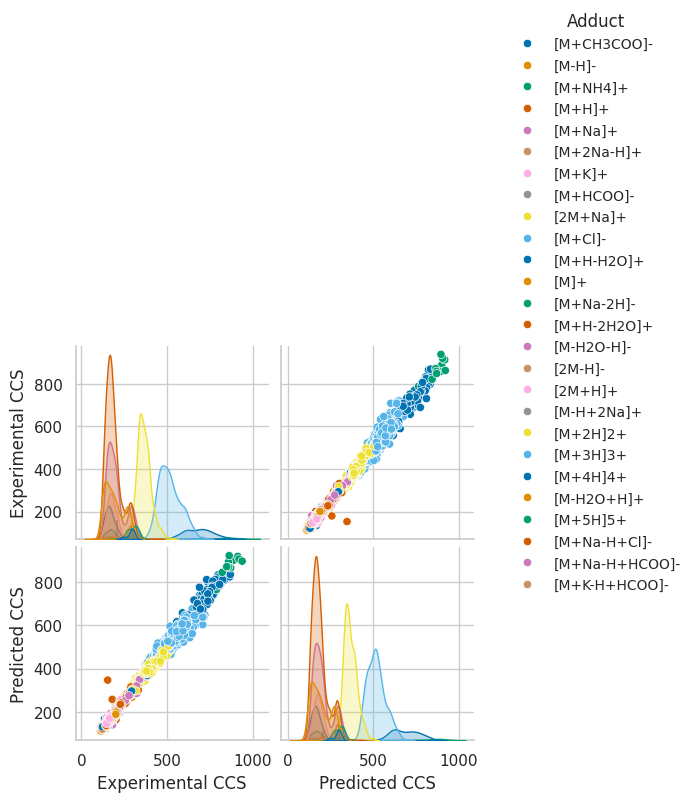

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Create the pairplot colored by Adduct instead of Cluster
g = sns.pairplot(df, vars=['CCS', 'Predicted_CCS'], hue='Adduct', palette='colorblind')

# Add a title to the whole figure
# g.fig.suptitle("Pairplot of Experimental vs. Predicted CCS by Adduct", fontsize=16)
g.fig.subplots_adjust(top=0.92)  # adjust space for title

# Set axis label font size
for ax in g.axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontsize=12)
    ax.set_ylabel(ax.get_ylabel(), fontsize=12)

# Optionally rename axis labels
label_map = {
    'CCS': 'Experimental CCS',
    'Predicted_CCS': 'Predicted CCS'
}
for ax in g.axes.flatten():
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()
    if xlabel in label_map:
        ax.set_xlabel(label_map[xlabel], fontsize=12)
    if ylabel in label_map:
        ax.set_ylabel(label_map[ylabel], fontsize=12)

# Update legend title and font size
g._legend.set_title("Adduct")
for text in g._legend.texts:
    text.set_fontsize(10)
g._legend.set_bbox_to_anchor((1, 1))  # Optional: move legend out if it's overlapping

# Save with high resolution
plt.savefig("pairplot_by_adduct.png", dpi=600, bbox_inches="tight")

# Show plot
plt.show()


/tmp/ipykernel_845/3458279537.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=12)


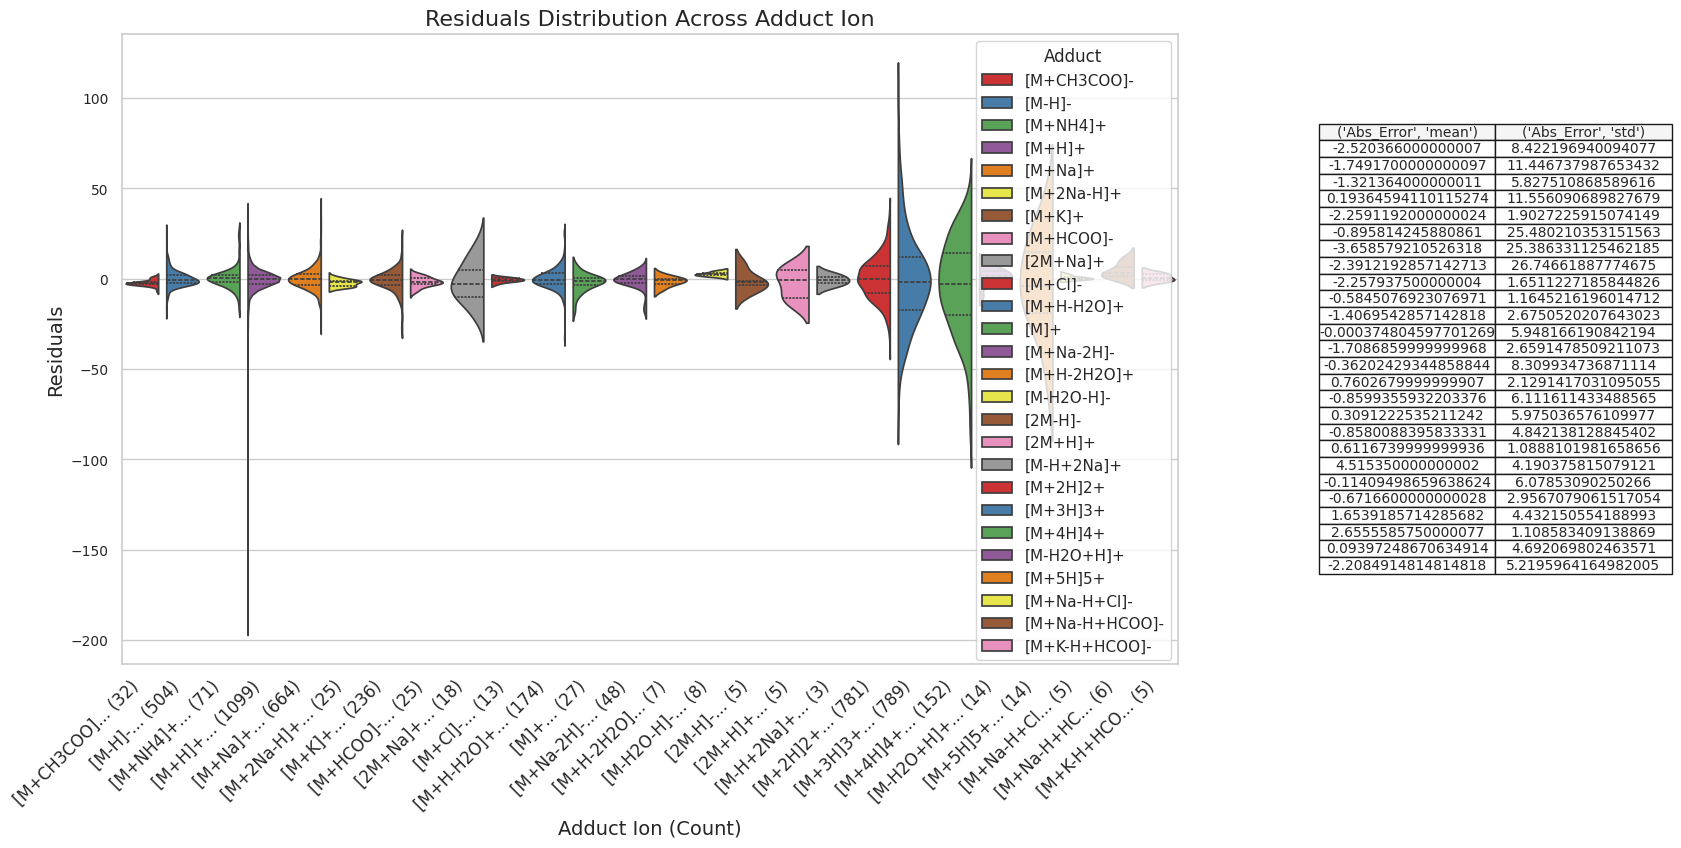

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute residuals
df['Abs_Error'] = (df['CCS'] - df['Predicted_CCS'])  # Use absolute difference

# Ensure Cluster is an integer and sort it numerically
df['Cluster'] = df['Cluster'].astype(int)

# Sort clusters numerically
sorted_clusters = sorted(df['Cluster'].unique())  # Sort the cluster labels in ascending order

# Apply sorted order to the Cluster column
df['Cluster'] = pd.Categorical(df['Cluster'], categories=sorted_clusters, ordered=True)

# Compute counts of each Adduct
adduct_counts = df['Adduct'].value_counts().to_dict()

# Create a mapping for labels with counts (using only the Adduct name)
df['Adduct_Labeled'] = df['Adduct'].map(lambda x: f"{x[:10]}... ({adduct_counts[x]})")  # Shorten label

# =========================
# تنظیمات publication-ready
# =========================
fig = plt.figure(figsize=(20, 10))  # Increase figure size for both the plot and the table

# Create a gridspec layout for the plot and the table
from matplotlib.gridspec import GridSpec
gs = GridSpec(nrows=1, ncols=2, width_ratios=[3, 1])  # 3x width for the plot and 1x for the table

# Create the subplot for the violin plot
ax1 = fig.add_subplot(gs[0])

# Violin plot with labeled Adduct as x-axis, Abs_Error as y-axis, and Cluster as hue
sns.violinplot(
    data=df, 
    x='Adduct_Labeled', 
    y='Abs_Error', 
    hue='Adduct', 
    palette='Set1', 
    split=True, 
    inner="quartile", 
    ax=ax1
)

# Labels and title with adjusted font size
ax1.set_xlabel("Adduct Ion (Count)", fontsize=14)
ax1.set_ylabel("Residuals", fontsize=14)
ax1.set_title("Residuals Distribution Across Adduct Ion", fontsize=16)

# Rotate x-axis labels for better readability and adjust distance from x-axis
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=12)
ax1.figure.subplots_adjust(bottom=0.25)  # Increase space for x-axis labels

# Create the subplot for the table
ax2 = fig.add_subplot(gs[1])

# Render the table in the second subplot
ax2.axis('off')  # Turn off the axis for the table
table_data = df[['Adduct_Labeled', 'Abs_Error']].groupby('Adduct_Labeled').agg(['mean', 'std'])
table = ax2.table(cellText=table_data.values, colLabels=table_data.columns, loc='center', cellLoc='center', colColours=['#f5f5f5']*len(table_data.columns))

# Table style adjustments
table.auto_set_font_size(False)
table.set_fontsize(10)

# =========================
# ذخیره خروجی
# =========================
plt.savefig(
    "absolute_residuals_violin_with_table.svg", 
    dpi=300, 
    bbox_inches="tight"
)
plt.savefig(
    "absolute_residuals_violin_with_table.png", 
    dpi=300, 
    bbox_inches="tight"
)

# نمایش نمودار
plt.show()


/tmp/ipykernel_845/1432699853.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Cluster_Labeled', y='Abs_Error', palette='colorblind', inner="quartile")


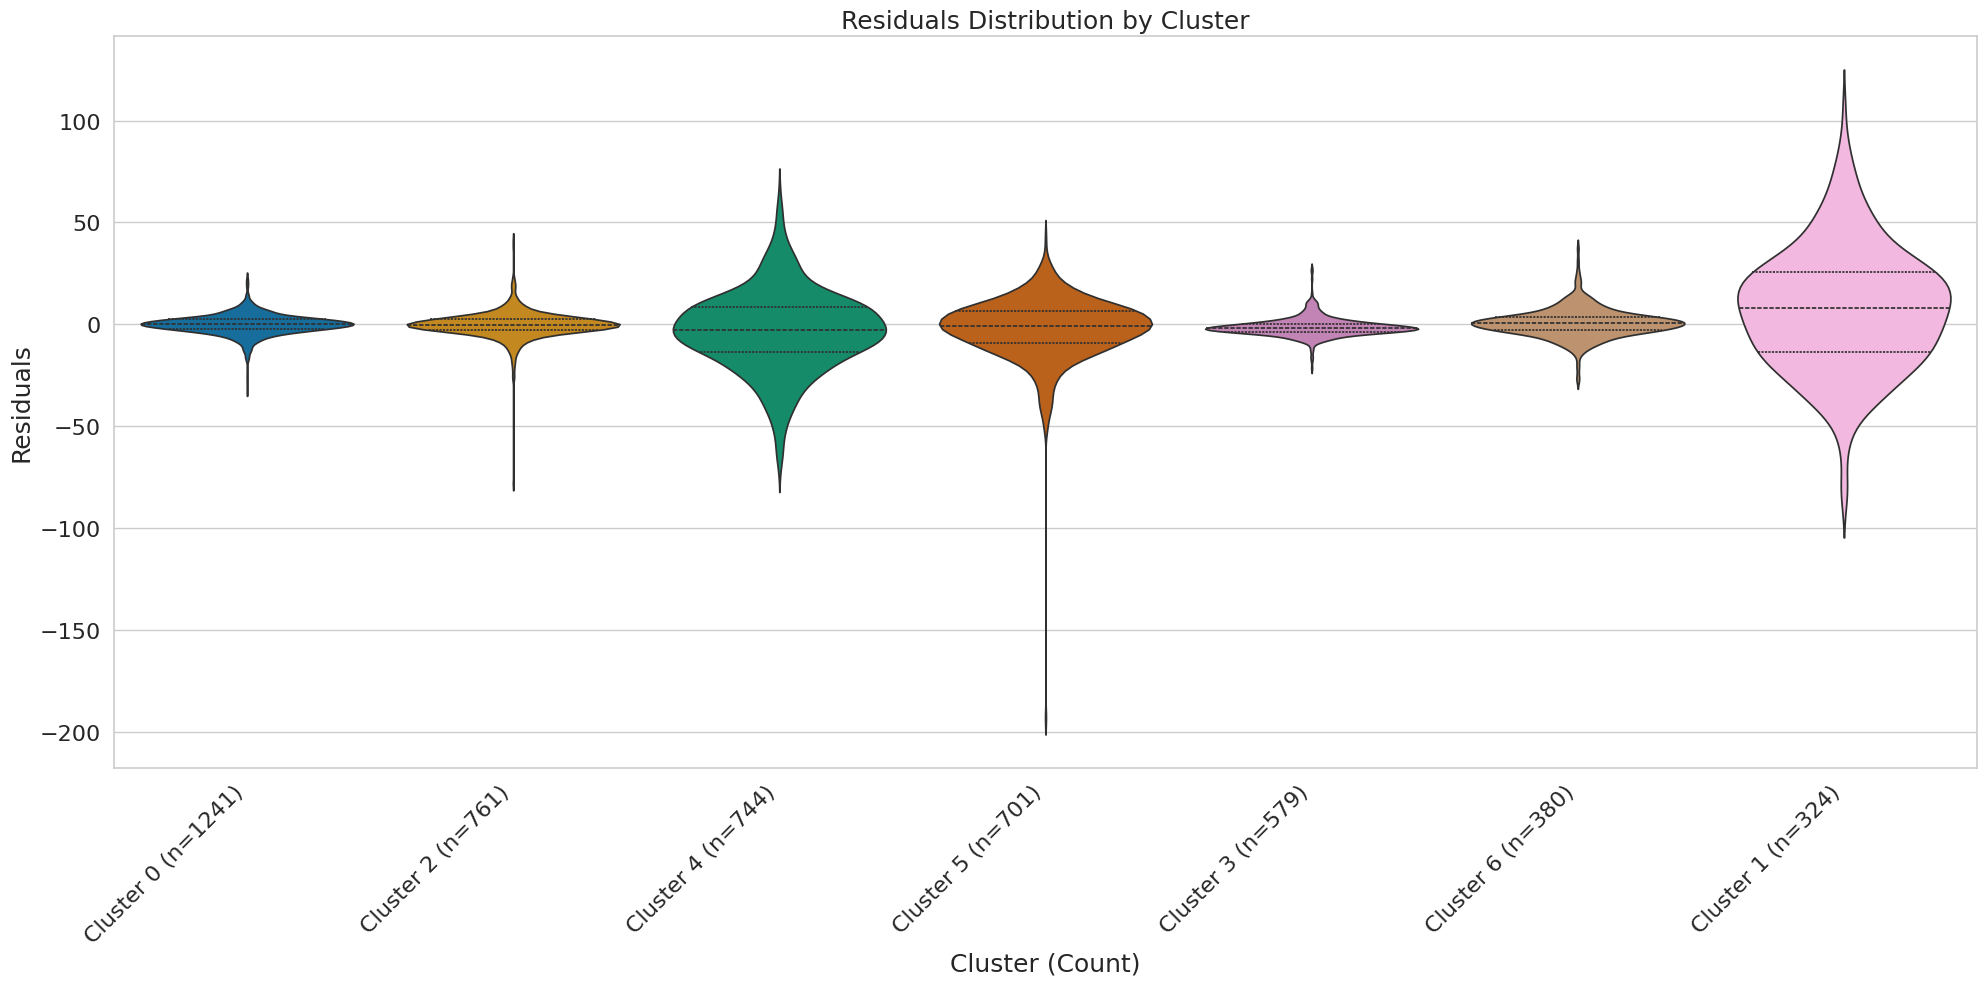

In [47]:


# فرض بر این است که df از قبل بارگذاری شده و داده‌ها در دسترس هستند
# Compute residuals (difference between CCS and Predicted CCS)
df['Abs_Error'] = df['CCS'] - df['Predicted_CCS']

# Ensure Cluster is an integer and sort it numerically
df['Cluster'] = df['Cluster'].astype(int)

# شمارش تعداد نمونه‌ها برای هر کلاستر
cluster_counts = df['Cluster'].value_counts()

# مرتب‌سازی کلاسترها بر اساس تعداد نمونه‌ها (بیشترین تعداد اول)
sorted_clusters_by_count = cluster_counts.sort_values(ascending=False).index.tolist()

# اعمال ترتیب جدید به کلاسترها
df['Cluster'] = pd.Categorical(df['Cluster'], categories=sorted_clusters_by_count, ordered=True)

# Create labels like "Cluster 0 (n=350)"
df['Cluster_Labeled'] = df['Cluster'].map(lambda x: f"Cluster {x} (n={cluster_counts[x]})")

# Create the figure with a larger size for clarity
plt.figure(figsize=(20, 10))

# Violin plot with labeled Clusters on x-axis and residuals on y-axis
sns.violinplot(data=df, x='Cluster_Labeled', y='Abs_Error', palette='colorblind', inner="quartile")

# Labels and title with adjusted font sizes
plt.xlabel("Cluster (Count)", fontsize=18)
plt.ylabel("Residuals", fontsize=18)
plt.title("Residuals Distribution by Cluster", fontsize=18)

# Rotate x-axis labels for better readability and adjust label sizes
plt.xticks(rotation=45, ha="right", fontsize=16)
plt.yticks(fontsize=16)

# Adjust layout to prevent overlapping of labels and plot
plt.tight_layout()

# Save the figure with high resolution for different formats
plt.savefig("cluster_residuals_sorted_by_count.png", dpi=300, bbox_inches="tight")
plt.savefig("cluster_residuals_sorted_by_count.pdf", dpi=300, bbox_inches="tight")
plt.savefig("cluster_residuals_sorted_by_count.svg", format="svg", dpi=96, bbox_inches="tight")

# Show the plot
plt.show()


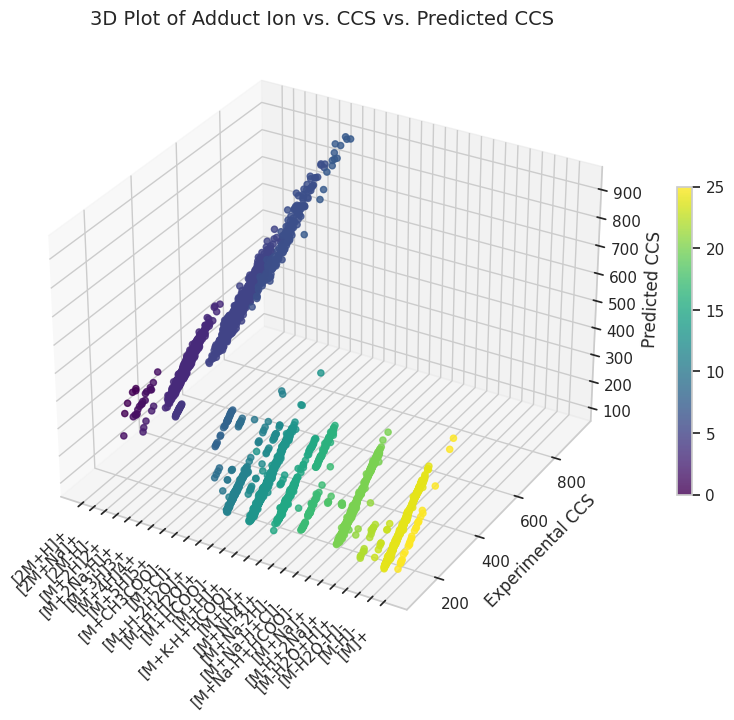

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Convert Adduct to categorical numerical values
df['Adduct_Num'] = df['Adduct'].astype('category').cat.codes  # Assign numerical codes to each adduct

# Create a 3D figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot in 3D
scatter = ax.scatter(df['Adduct_Num'], df['CCS'], df['Predicted_CCS'], c=df['Adduct_Num'], cmap='viridis', alpha=0.8)

# Labeling the axes
ax.set_xlabel("Adduct Ion (Encoded)", fontsize=1)
ax.set_ylabel("Experimental CCS", fontsize=12)
ax.set_zlabel("Predicted CCS", fontsize=12)
ax.set_title("3D Plot of Adduct Ion vs. CCS vs. Predicted CCS", fontsize=14)

# Convert numerical labels back to categorical names for ticks
adduct_labels = dict(enumerate(df['Adduct'].astype('category').cat.categories))
ax.set_xticks(list(adduct_labels.keys()))
ax.set_xticklabels(list(adduct_labels.values()), rotation=45, ha="right")

# Show color bar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("")

# Show plot
plt.show()


/tmp/ipykernel_842/1479496380.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Adduct', y='Abs_Error', palette='colorblind', showfliers=False)


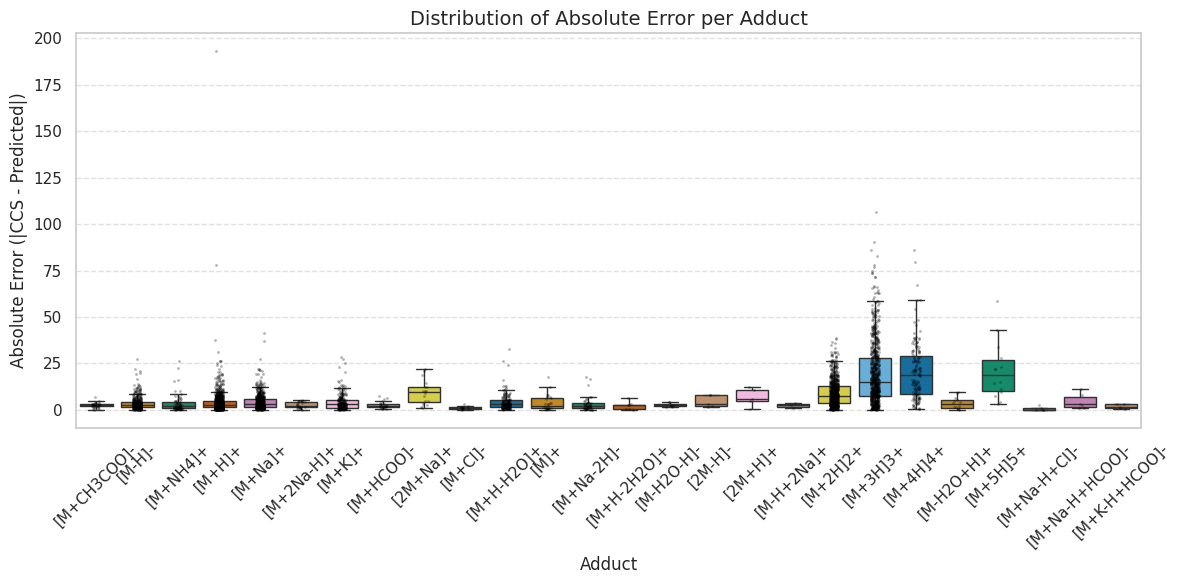

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ساختن ستون خطای مطلق
df['Abs_Error'] = np.abs(df['CCS'] - df['Predicted_CCS'])

# سایز شکل
plt.figure(figsize=(12, 6))

# جعبه‌ای + نقاط پراکنده برای هر Adduct
sns.boxplot(data=df, x='Adduct', y='Abs_Error', palette='colorblind', showfliers=False)
sns.stripplot(data=df, x='Adduct', y='Abs_Error', color='black', size=2, alpha=0.3, jitter=True)

# برچسب‌ها و عنوان
plt.ylabel("Absolute Error (|CCS - Predicted|)", fontsize=12)
plt.xlabel("Adduct", fontsize=12)
plt.title("Distribution of Absolute Error per Adduct", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


/tmp/ipykernel_842/650273169.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Adduct', y='Abs_Error', palette='colorblind', showfliers=False)


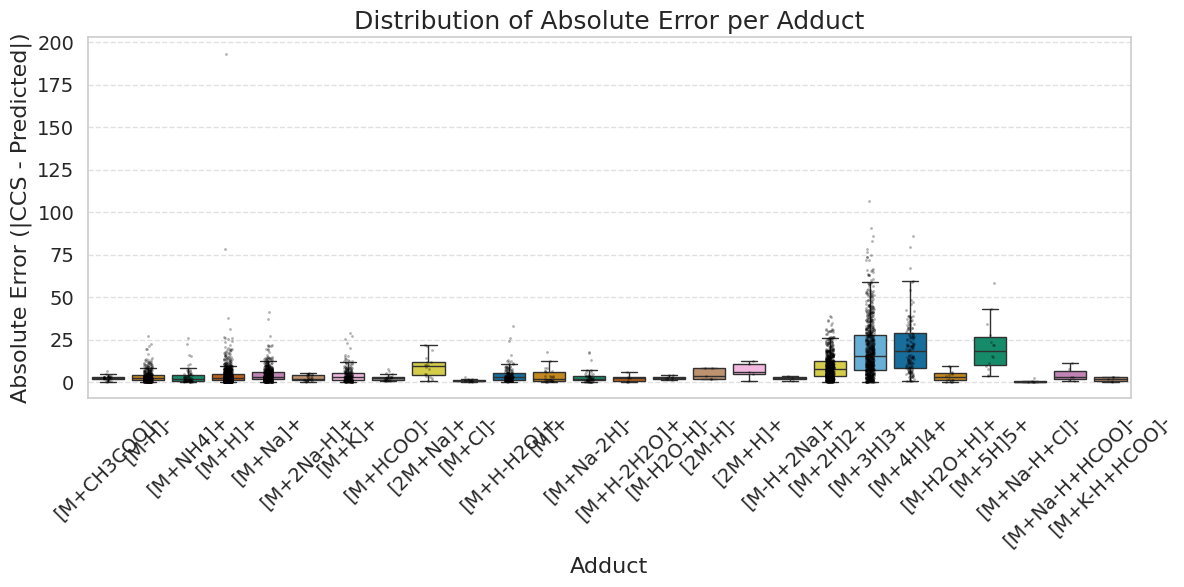

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# تنظیمات فونت‌ها قبل از رسم نمودار
plt.rcParams.update({
    "font.family": "sans-serif",  # فونت مناسب مقاله
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "svg.fonttype": "none"  # فونت‌ها قابل انتخاب و ویرایش
})

# ساختن ستون خطای مطلق
df['Abs_Error'] = np.abs(df['CCS'] - df['Predicted_CCS'])

# سایز شکل
plt.figure(figsize=(12, 6))

# جعبه‌ای + نقاط پراکنده برای هر Adduct
sns.boxplot(data=df, x='Adduct', y='Abs_Error', palette='colorblind', showfliers=False)
sns.stripplot(data=df, x='Adduct', y='Abs_Error', color='black', size=2, alpha=0.3, jitter=True)

# برچسب‌ها و عنوان
plt.ylabel("Absolute Error (|CCS - Predicted|)", fontsize=16)
plt.xlabel("Adduct", fontsize=16)
plt.title("Distribution of Absolute Error per Adduct", fontsize=18)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# تنظیمات برای جلوگیری از تداخل برچسب‌ها
plt.tight_layout()

# ذخیره نمودار با فرمت SVG و قابل ویرایش
plt.savefig("absolute_error_distribution.svg", format="svg", dpi=300, bbox_inches="tight")

# نمایش نمودار
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


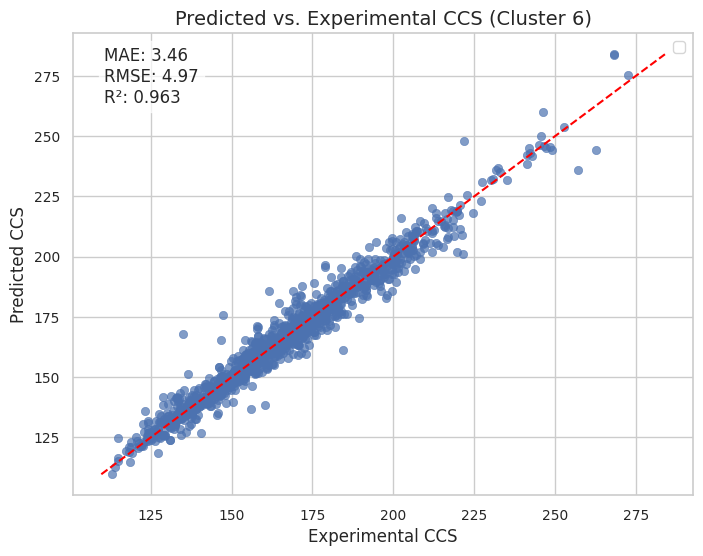

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter the dataset for Cluster 6
df_cluster6 = df[df['Cluster'] == 0]

# Compute error metrics
mae = mean_absolute_error(df_cluster6['CCS'], df_cluster6['Predicted_CCS'])
rmse = np.sqrt(mean_squared_error(df_cluster6['CCS'], df_cluster6['Predicted_CCS']))
r2 = r2_score(df_cluster6['CCS'], df_cluster6['Predicted_CCS'])

# Create a 2D scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cluster6, x='CCS', y='Predicted_CCS', alpha=0.7, edgecolor=None)

# Plot y = x line (perfect predictions)
min_val = min(df_cluster6['CCS'].min(), df_cluster6['Predicted_CCS'].min())
max_val = max(df_cluster6['CCS'].max(), df_cluster6['Predicted_CCS'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)

# Annotate error metrics
metrics_text = f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.3f}"
plt.annotate(metrics_text, xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

# Labels and title
plt.xlabel("Experimental CCS", fontsize=12)
plt.ylabel("Predicted CCS", fontsize=12)
plt.title("Predicted vs. Experimental CCS (Cluster 6)", fontsize=14)
plt.legend()

# Show plot
plt.show()


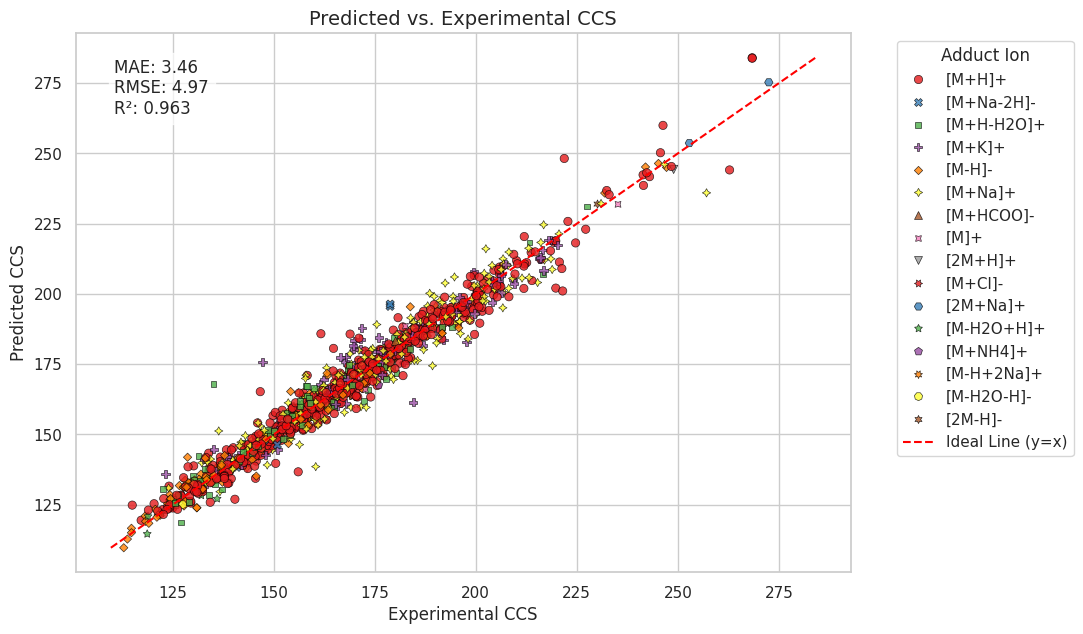

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter the dataset for Cluster 6
df_cluster6 = df[df['Cluster'] == 0]

# Compute error metrics
mae = mean_absolute_error(df_cluster6['CCS'], df_cluster6['Predicted_CCS'])
rmse = np.sqrt(mean_squared_error(df_cluster6['CCS'], df_cluster6['Predicted_CCS']))
r2 = r2_score(df_cluster6['CCS'], df_cluster6['Predicted_CCS'])

# Create a 2D scatter plot with Adduct as hue
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=df_cluster6, x='CCS', y='Predicted_CCS', hue='Adduct', style='Adduct',
    palette='Set1', alpha=0.8, edgecolor='black'
)

# Plot y = x line (perfect predictions)
min_val = min(df_cluster6['CCS'].min(), df_cluster6['Predicted_CCS'].min())
max_val = max(df_cluster6['CCS'].max(), df_cluster6['Predicted_CCS'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label="Ideal Line (y=x)")

# Annotate error metrics
metrics_text = f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.3f}"
plt.annotate(metrics_text, xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

# Labels and title
plt.xlabel("Experimental CCS", fontsize=12)
plt.ylabel("Predicted CCS", fontsize=12)
plt.title("Predicted vs. Experimental CCS", fontsize=14)
plt.legend(title="Adduct Ion", bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside

plt.savefig("Predicted vs. Experimental CCS.png", dpi=300, bbox_inches="tight")  # Higher DPI for clarity

# Show plot
plt.show()


In [41]:
print(final_table)
print(final_table.shape)

Empty DataFrame
Columns: [Adduct Ion, Count, MDRE, MRE, MDAE, MAE, RMSE, R²]
Index: []
(0, 8)


In [14]:
for adduct, sub_df in df_cluster.groupby('Adduct'):
    adduct_count = adduct_counts[adduct]

    y_true = sub_df['CCS'].values
    y_pred = sub_df['Predicted_CCS'].values

    abs_error = np.abs(y_true - y_pred)
    rel_error = abs_error / y_true

    mae = mean_absolute_error(y_true, y_pred)
    mdae = np.median(abs_error)
    mre = np.mean(rel_error)
    mdre = np.median(rel_error)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    stats.append([
        adduct,
        adduct_count,
        round(mae, 2),
        round(mdae, 2),
        round(mre, 3),
        round(mdre, 3),
        round(rmse, 2),
        round(r2, 2)
    ])


/home/amir/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/amir/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/amir/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/amir/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/amir/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two

/tmp/ipykernel_5304/3072773084.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster_Labeled', y='Abs_Error', palette='viridis', showfliers=False)


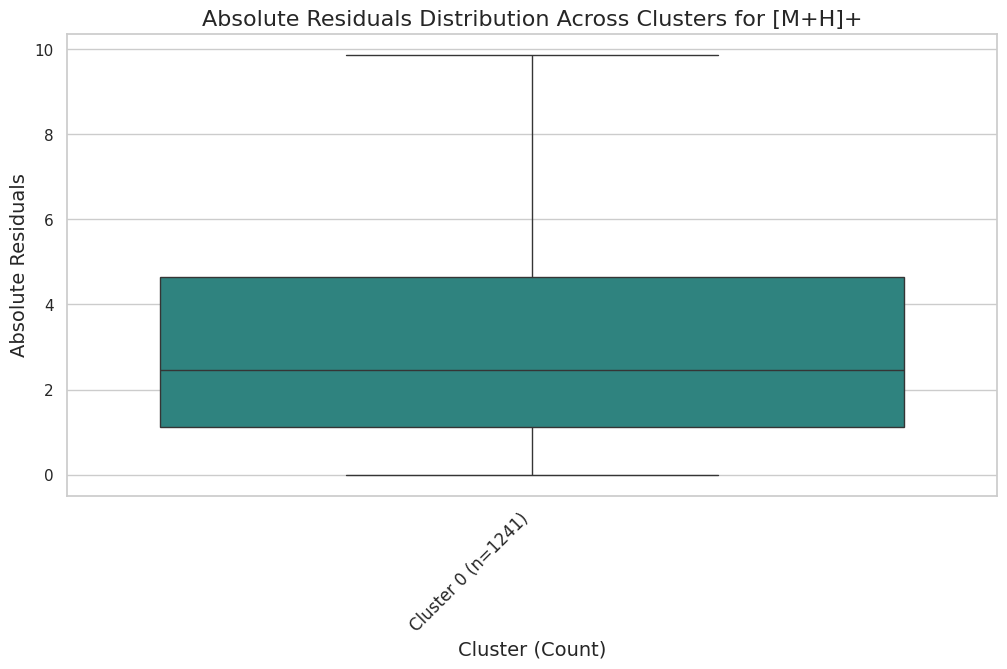

In [15]:

#### import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute residuals
df['Abs_Error'] = np.abs(df['CCS'] - df['Predicted_CCS'])  # Absolute error

# Ensure Cluster is an integer and sort it numerically
df['Cluster'] = df['Cluster'].astype(int)

# Compute counts of each Cluster
cluster_counts = df['Cluster'].value_counts().to_dict()

# Sort clusters numerically
sorted_clusters = sorted(cluster_counts.keys())

# Apply sorted order to the Cluster column
df['Cluster'] = pd.Categorical(df['Cluster'], categories=sorted_clusters, ordered=True)

# Create a mapping for labels with counts
df['Cluster_Labeled'] = df['Cluster'].map(lambda x: f"Cluster {x} (n={cluster_counts[x]})")

# Create a larger figure
plt.figure(figsize=(12, 6))  # Adjusted size for better visibility

# Box plot with labeled Cluster on X-axis and Abs_Error on Y-axis
sns.boxplot(data=df, x='Cluster_Labeled', y='Abs_Error', palette='viridis', showfliers=False)

# Labels and title
plt.xlabel("Cluster (Count)", fontsize=14)
plt.ylabel("Absolute Residuals", fontsize=14)
plt.title(f"Absolute Residuals Distribution Across Clusters for {df['Adduct'].iloc[0]}", fontsize=16)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right", fontsize=12)

# Save the figure
plt.savefig("absolute_residuals_per_cluster_with_counts.png", dpi=600, bbox_inches="tight")

# Show the plot
plt.show()


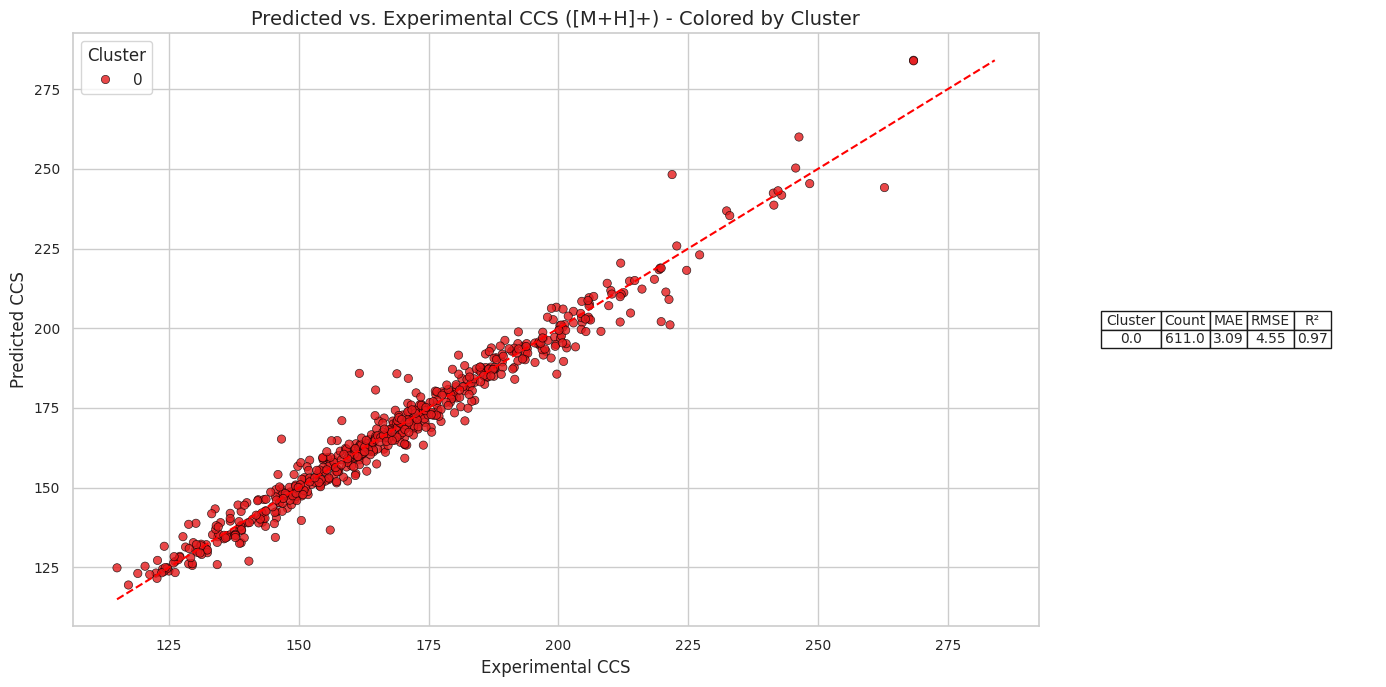

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure Cluster is an integer and sort it numerically
df['Cluster'] = df['Cluster'].astype(int)

# Filter data for only ONE Adduct Ion (assuming only one Adduct exists)
adduct_name = df['Adduct'].unique()[0]  # Get the single Adduct Ion present
df_adduct = df[df['Adduct'] == adduct_name]  # Filter dataset for the single Adduct

# Compute statistics for each Cluster
stats = []
for cluster, sub_df in df_adduct.groupby('Cluster'):
    cluster_count = len(sub_df)
    mae = mean_absolute_error(sub_df['CCS'], sub_df['Predicted_CCS'])
    rmse = np.sqrt(mean_squared_error(sub_df['CCS'], sub_df['Predicted_CCS']))
    r2 = r2_score(sub_df['CCS'], sub_df['Predicted_CCS'])
    stats.append([cluster, cluster_count, round(mae, 2), round(rmse, 2), round(r2, 2)])

# Convert to DataFrame
stats_df = pd.DataFrame(stats, columns=['Cluster', 'Count', 'MAE', 'RMSE', 'R²'])

# Create figure with 2 subplots (scatter plot + statistics table)
fig, ax = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [3, 1]})  # Adjust layout

# ---- PLOT 1: Scatter Plot (Cluster as Hue) ----
scatter = sns.scatterplot(
    data=df_adduct, x='CCS', y='Predicted_CCS', hue='Cluster', style='Cluster',
    palette='Set1', alpha=0.8, edgecolor='black', ax=ax[0]
)

# Plot y = x line (ideal line)
min_val = min(df_adduct['CCS'].min(), df_adduct['Predicted_CCS'].min())
max_val = max(df_adduct['CCS'].max(), df_adduct['Predicted_CCS'].max())
ax[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label="Ideal Line (y=x)")

# Labels and title
ax[0].set_xlabel("Experimental CCS", fontsize=12)
ax[0].set_ylabel("Predicted CCS", fontsize=12)
ax[0].set_title(f"Predicted vs. Experimental CCS ({adduct_name}) - Colored by Cluster", fontsize=14)

# ---- PLOT 2: Statistics Table ----
ax[1].axis("tight")
ax[1].axis("off")
table = ax[1].table(cellText=stats_df.values, colLabels=stats_df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width([0, 1, 2, 3, 4])  # Adjust column width

# Adjust layout & save
plt.tight_layout()
plt.savefig("scatterplot_with_cluster_table.png", dpi=600, bbox_inches="tight")  # Save the figure
plt.show()


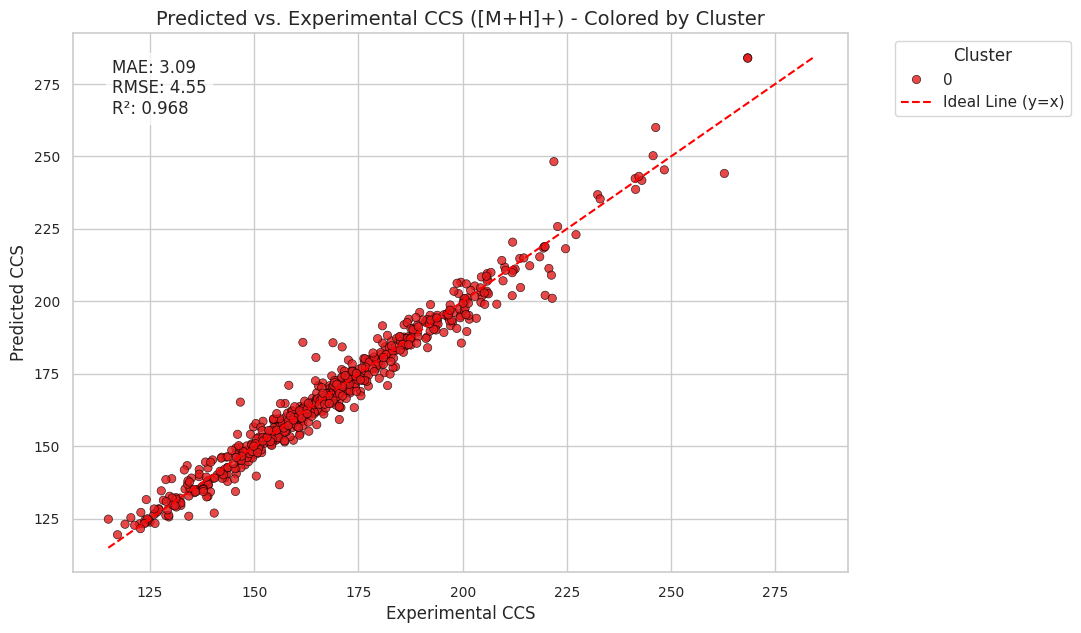

In [40]:
### import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure Cluster is an integer for correct sorting
df['Cluster'] = df['Cluster'].astype(int)

# Filter dataset for only **one Adduct Ion**
adduct_name = df['Adduct'].unique()[0]  # Assuming dataset contains only one Adduct
df_adduct = df[df['Adduct'] == adduct_name]  # Filter dataset

# Compute error metrics for the entire dataset
mae = mean_absolute_error(df_adduct['CCS'], df_adduct['Predicted_CCS'])
rmse = np.sqrt(mean_squared_error(df_adduct['CCS'], df_adduct['Predicted_CCS']))
r2 = r2_score(df_adduct['CCS'], df_adduct['Predicted_CCS'])

# Create a 2D scatter plot with **Cluster as Hue**
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_adduct, x='CCS', y='Predicted_CCS', hue='Cluster', style='Cluster',
    palette='Set1', alpha=0.8, edgecolor='black'
)

# Plot y = x line (perfect predictions)
min_val = min(df_adduct['CCS'].min(), df_adduct['Predicted_CCS'].min())
max_val = max(df_adduct['CCS'].max(), df_adduct['Predicted_CCS'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label="Ideal Line (y=x)")

# Annotate error metrics
metrics_text = f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {r2:.3f}"
plt.annotate(metrics_text, xy=(0.05, 0.85), xycoords='axes fraction', fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

# Labels and title
plt.xlabel("Experimental CCS", fontsize=12)
plt.ylabel("Predicted CCS", fontsize=12)
plt.title(f"Predicted vs. Experimental CCS ({adduct_name}) - Colored by Cluster", fontsize=14)

# Adjust legend position
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()


/tmp/ipykernel_5304/104288131.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adduct['Absolute Error'] = (df_adduct['CCS'] - df_adduct['Predicted_CCS'])
/tmp/ipykernel_5304/104288131.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_adduct['Cluster_Labeled'] = df_adduct['Cluster'].map(lambda c: f"Cluster {c}\n(n={cluster_counts[c]})")
/tmp/ipykernel_5304/104288131.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

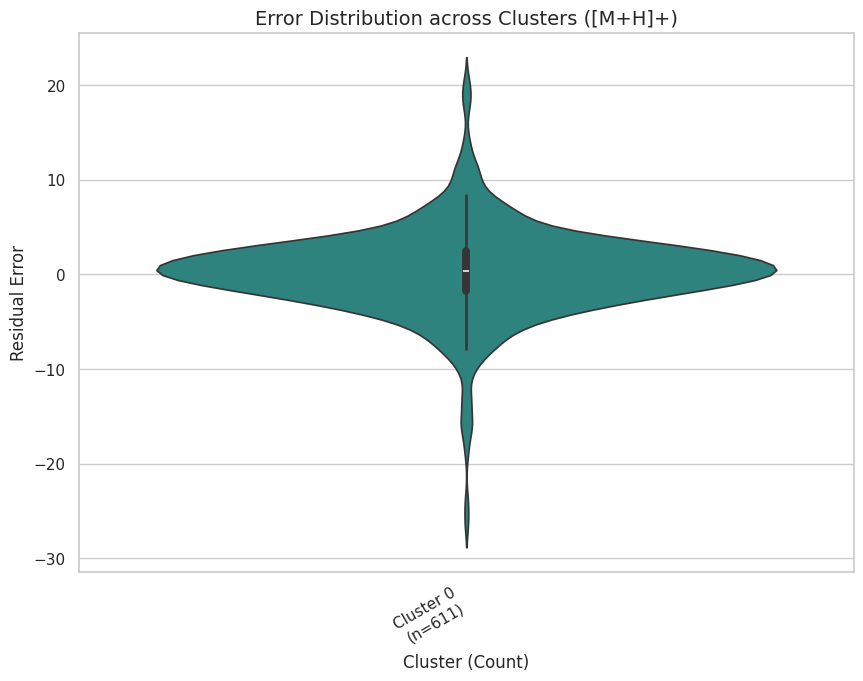

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure Cluster is an integer for correct sorting
df['Cluster'] = df['Cluster'].astype(int)

# Filter dataset for only **one Adduct Ion**
adduct_name = df['Adduct'].unique()[0]  # Assuming dataset contains only one Adduct
df_adduct = df[df['Adduct'] == adduct_name]  # Filter dataset

# Compute Absolute Error (|CCS - Predicted CCS|)
# df_adduct['Absolute Error'] = np.abs(df_adduct['CCS'] - df_adduct['Predicted_CCS'])
df_adduct['Absolute Error'] = (df_adduct['CCS'] - df_adduct['Predicted_CCS'])

# Count number of occurrences per Cluster
cluster_counts = df_adduct['Cluster'].value_counts().to_dict()

# Create a new column for labeled clusters (e.g., "Cluster 1 (n=50)")
df_adduct['Cluster_Labeled'] = df_adduct['Cluster'].map(lambda c: f"Cluster {c}\n(n={cluster_counts[c]})")

# Sort clusters numerically
sorted_clusters = sorted(df_adduct['Cluster'].unique())  # Get sorted cluster numbers
sorted_labels = [f"Cluster {c}\n(n={cluster_counts[c]})" for c in sorted_clusters]  # Ensure labels are sorted

# Convert Cluster_Labeled into a categorical type with the correct order
df_adduct['Cluster_Labeled'] = pd.Categorical(df_adduct['Cluster_Labeled'], categories=sorted_labels, ordered=True)

# Create a violin plot for error distribution by Cluster
plt.figure(figsize=(10, 7))
sns.violinplot(
    data=df_adduct, x='Cluster_Labeled', y='Absolute Error', palette='viridis', inner='box'
)

# Labels and title
plt.xlabel("Cluster (Count)", fontsize=12)
plt.ylabel("Residual Error", fontsize=12)
plt.title(f"Error Distribution across Clusters ({adduct_name})", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha="right")

# Show plot
plt.show()


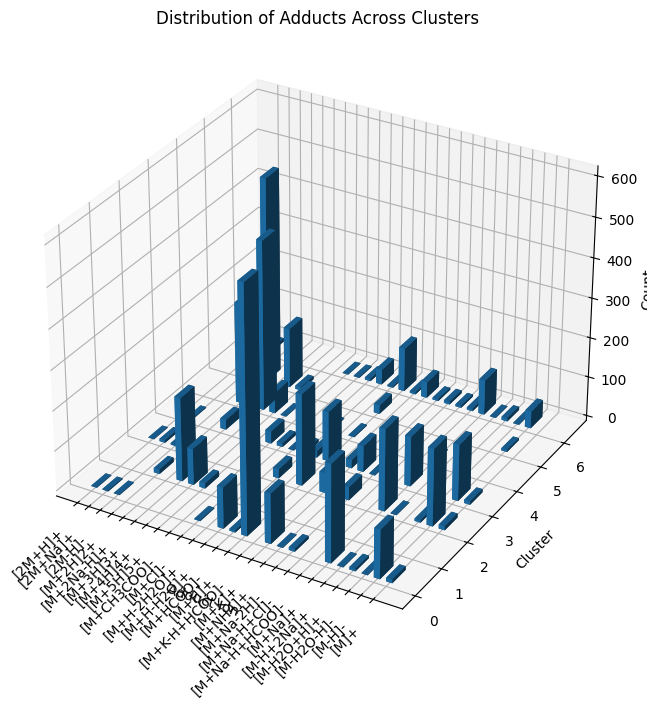

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Count occurrences of each Adduct in each Cluster
adduct_cluster_counts = df.groupby(['Adduct', 'Cluster']).size().reset_index(name='Count')

# Convert categorical variables to numerical indices for plotting
adduct_labels = adduct_cluster_counts['Adduct'].unique()
cluster_labels = sorted(adduct_cluster_counts['Cluster'].unique())  # Sort clusters numerically

adduct_mapping = {adduct: i for i, adduct in enumerate(adduct_labels)}
cluster_mapping = {cluster: i for i, cluster in enumerate(cluster_labels)}

adduct_cluster_counts['Adduct_Index'] = adduct_cluster_counts['Adduct'].map(adduct_mapping)
adduct_cluster_counts['Cluster_Index'] = adduct_cluster_counts['Cluster'].map(cluster_mapping)

# Create 3D bar plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract data for plotting
x = adduct_cluster_counts['Adduct_Index']
y = adduct_cluster_counts['Cluster_Index']
z = np.zeros(len(adduct_cluster_counts))  # Start bars from z=0
dx = dy = 0.5  # Width of bars
dz = adduct_cluster_counts['Count']  # Height of bars

# Create bars
ax.bar3d(x, y, z, dx, dy, dz, shade=True)

# Set labels
ax.set_xlabel("Adduct Ion")
ax.set_ylabel("Cluster")
ax.set_zlabel("Count")
ax.set_title("Distribution of Adducts Across Clusters")

# Set custom tick labels
ax.set_xticks(range(len(adduct_labels)))
ax.set_xticklabels(adduct_labels, rotation=45, ha="right")

ax.set_yticks(range(len(cluster_labels)))
ax.set_yticklabels(cluster_labels)

plt.show()
